# Magnetic Field Evolution in Satellite Galaxies
## PHY 225-001
**Author:** Mariane Diby | Adelphi University

**Scientific Goal:**
McDonough & Poulin (2025) showed that satellite galaxies in TNG100 have magnetic fields ~10x stronger than centrals at fixed stellar mass. This notebook investigates *when* and *how fast* this amplification occurs by reconstructing each satellite's full magnetic field history using merger tree data, identifying the moment of infall, and applying Gaussian kernel smoothing to extract clean trends from the noisy simulation outputs.

---
### Notebook Structure
1. Setup & Imports
2. Build Snapshot → Redshift / Lookback-Time Table
3. Query Satellite Galaxies at z=0 (SubhaloGrNr = 0)
4. Walk the Merger Tree (Main Progenitor Branch)
5. Identify Infall Time (central → satellite transition)
6. Plot Raw B-field vs Redshift
7. Generalize to Multiple Galaxies
8. Kernel Smoothing + LOOCV Bandwidth Selection
9. Smoothed B-field vs Time Since Infall (Key Science Plot)
10. Individual Exponential Fits + Distribution of Timescales

---
## 1. Setup & Imports

This cell imports all required Python libraries and sets up the output folder structure.
All figures are saved to `results/figures/` and all merger tree HDF5 files are cached in `trees/`,
both located at the **repository root** (one level above the `notebooks/` folder where this file lives).

In [5]:
import numpy as np                          # numerical arrays and math
import matplotlib.pyplot as plt             # plotting
import h5py                                 # reading HDF5 merger tree files from TNG
import os                                   # file system operations
import pickle                               # saving/loading processed data to disk
import pathlib                              # path handling across operating systems
import astropy.units as u                   # physical units
from astropy.cosmology import FlatLambdaCDM # cosmological calculations (lookback time)
from scipy.optimize import curve_fit        # nonlinear least-squares fitting
from scipy.interpolate import interp1d      # 1D interpolation for ensemble grid

# iapi.py is the TNG API helper provided by the workshop
# It must be in the same directory as this notebook
import iapi

# ── Cosmological parameters ───────────────────────────────────────────────────
# TNG100-1 uses Planck 2015 cosmology
cosmo    = FlatLambdaCDM(H0=67.74, Om0=0.3089)  # H0 in km/s/Mpc, Om0 = matter density
SIM_NAME = 'TNG100-1'                            # simulation name for API calls
h_cosmo  = 0.6774                                # dimensionless Hubble parameter (used for unit conversions)

# ── Output folder setup ───────────────────────────────────────────────────────
# repo_root points to the top-level repository folder
# pathlib.Path.cwd() is the current working directory (notebooks/)
# .parent goes up one level to the repo root
repo_root = pathlib.Path.cwd().parent

# Create output directories at the repo root if they don't already exist
# exist_ok=True means no error if the folder already exists
os.makedirs(repo_root / 'trees',            exist_ok=True)  # HDF5 merger tree cache
os.makedirs(repo_root / 'results/figures',  exist_ok=True)  # output figures
os.makedirs(repo_root / 'data/processed',   exist_ok=True)  # processed .pkl cache

# Convenience string paths for savefig calls
FIG_DIR  = repo_root / 'results' / 'figures'
TREE_DIR = repo_root / 'trees'
DATA_DIR = repo_root / 'data' / 'processed'

# ── API connectivity test ─────────────────────────────────────────────────────
# A quick check that the API key in iapi.py is valid and the server is reachable
try:
    info = iapi.get(iapi.baseUrl + SIM_NAME + '/')
    print(f'Connected to {SIM_NAME}')
    print(f'Available keys: {list(info.keys())}')
except Exception as e:
    print(f'Connection failed — check the API key in iapi.py: {e}')

Connected to TNG100-1
Available keys: ['name', 'description', 'name_alt', 'boxsize', 'z_start', 'z_final', 'cosmology', 'omega_0', 'omega_L', 'omega_B', 'hubble', 'physics_model', 'has_cooling', 'has_starformation', 'has_winds', 'has_blackholes', 'mass_gas', 'mass_dm', 'softening_dm_comoving', 'softening_stars_comoving', 'softening_blackholes_comoving', 'softening_gas_comoving', 'softening_dm_max_phys', 'softening_stars_max_phys', 'softening_blackholes_max_phys', 'softening_gas_max_phys', 'softening_gas_factor', 'softening_gas_comoving_min', 'num_dm', 'num_tr_mc', 'num_tr_vel', 'longids', 'is_uniform', 'is_zoom', 'is_subbox', 'num_files_snapshot', 'num_files_groupcat', 'num_files_rockstar', 'num_files_lhalotree', 'num_files_sublink', 'num_files_ctrees', 'filesize_lhalotree', 'filesize_sublink', 'filesize_ctrees', 'filesize_ics', 'filesize_simulation', 'has_fof', 'has_subfind', 'has_rockstar', 'has_lhalotree', 'has_sublink', 'has_ctrees', 'permission_required', 'num_snapshots', 'url', '

---
## 2. Build the Snapshot → Redshift / Lookback-Time Table

TNG100-1 has 100 snapshots spanning from z ≈ 20 (early universe) to z = 0 (today).
Each snapshot is a moment in time identified by a snapshot number (0 = earliest, 99 = z=0).

We build a lookup table that maps each snapshot number to:
- **redshift z**: how far the light has been stretched since that moment
- **scale factor a = 1/(1+z)**: the relative size of the universe at that time
- **lookback time (Gyr)**: how many billion years ago that snapshot corresponds to

All smoothing and analysis is done in **lookback time** (not redshift), because the snapshots
are non-uniformly spaced in lookback time and operations on redshift values can distort results.

In [6]:
def build_snapshot_table(sim_name=SIM_NAME):
    """
    Download snapshot metadata from the TNG API and build a lookup table.

    For each of the 100 TNG snapshots, we record:
      - redshift z
      - scale factor a = 1/(1+z)
      - lookback time in Gyr, computed using the Planck 2015 flat LCDM cosmology

    The lookback time integral is:
        t_lb(z) = integral from 0 to z of dz' / [(1+z') * H(z')]
    where H(z) = H0 * sqrt(Om0*(1+z)^3 + OmLambda)

    Parameters
    ----------
    sim_name : str, TNG simulation name (default: 'TNG100-1')

    Returns
    -------
    table : dict mapping snapshot number (int) -> {redshift, scale_factor, lookback_time}
    """
    snaps_info = iapi.get(iapi.baseUrl + sim_name + '/snapshots/')
    table = {}
    for s in snaps_info:
        z  = s['redshift']
        # cosmo.lookback_time returns an astropy Quantity; .value extracts the float in Gyr
        lb = cosmo.lookback_time(z).to(u.Gyr).value
        table[s['number']] = {
            'redshift'      : z,
            'scale_factor'  : 1.0 / (1.0 + z),
            'lookback_time' : lb,   # Gyr
        }
    return table


# Build the table once — reused throughout the notebook
SNAP_TABLE = build_snapshot_table()

# Preview a few rows to verify the conversion is working
print(f"{'Snap':>5}  {'z':>8}  {'a':>8}  {'Lookback (Gyr)':>15}")
print('-' * 45)
for sn in [0, 10, 33, 50, 67, 78, 91, 99]:
    row = SNAP_TABLE[sn]
    print(f"{sn:>5}  {row['redshift']:>8.3f}  {row['scale_factor']:>8.4f}  {row['lookback_time']:>15.3f}")

 Snap         z         a   Lookback (Gyr)
---------------------------------------------
    0    20.046    0.0475           13.623
   10     7.236    0.1214           13.071
   33     2.002    0.3331           10.518
   50     0.997    0.5007            7.925
   67     0.503    0.6653            5.216
   78     0.298    0.7706            3.504
   91     0.099    0.9096            1.336
   99     0.000    1.0000            0.000


---
## 3. Query Satellite Galaxies at z = 0

In TNG, each galaxy is a **subhalo** — a group of gravitationally bound particles identified by the SUBFIND algorithm.
Within any Friends-of-Friends (FoF) halo, the most massive subhalo is the **central** galaxy;
all others are **satellites** (`primary_flag = 0`).

We focus on satellites with `SubhaloGrNr = 0` — meaning they belong to **FoF group 0**,
the most massive halo in the simulation. This gives a clean, controlled sample
all sharing the same host environment, which makes the exponential fit more meaningful.

In [7]:
def query_satellites(snap=99, stellar_mass_min_log=8.0, stellar_mass_max_log=13.0,
                     limit=50, grnr=0):
    """
    Query the TNG API for satellite subhalos at a given snapshot.

    Satellites are subhalos with primary_flag=0, meaning they are NOT
    the most massive subhalo in their FoF group (i.e., not a central galaxy).

    We filter by SubhaloGrNr to select only satellites belonging to a specific
    FoF halo. grnr=0 selects the most massive halo in the simulation.

    Parameters
    ----------
    snap                 : int, snapshot number (99 = z=0)
    stellar_mass_min_log : float, minimum log10(M*/Msun)
    stellar_mass_max_log : float, maximum log10(M*/Msun)
    limit                : int, max number of subhalos to return
    grnr                 : int or None, FoF group number filter (0 = most massive halo)

    Returns
    -------
    galaxies : list of dicts with keys: id, mass_log_msun, url
    """
    url    = iapi.baseUrl + SIM_NAME + f'/snapshots/{snap}/subhalos/'
    params = {
        'primary_flag'      : 0,                    # satellites only
        'mass_log_msun__gte': stellar_mass_min_log,  # lower stellar mass bound
        'mass_log_msun__lte': stellar_mass_max_log,  # upper stellar mass bound
        'limit'             : limit,
    }
    # Optionally filter to a specific FoF group number
    if grnr is not None:
        params['SubhaloGrNr'] = grnr

    result   = iapi.get(url, params=params)
    galaxies = result.get('results', [])
    print(f"Found {result['count']} satellites in FoF group {grnr}; returning {len(galaxies)}.")
    return galaxies


# Pull all satellites of the most massive halo (SubhaloGrNr = 0)
# These all share the same host environment, giving a controlled sample
satellites_z0 = query_satellites(snap=99, stellar_mass_min_log=8.0, grnr=0, limit=50)

# Print all returned IDs so we can see what we're working with
print(f"\n{'#':>3}  {'SubhaloID':>10}  {'log M*':>8}")
print('-' * 28)
for i, g in enumerate(satellites_z0):
    print(f"{i:>3}  {g['id']:>10d}  {g['mass_log_msun']:>8.3f}")

Found 940505 satellites in FoF group 0; returning 50.

  #   SubhaloID    log M*
----------------------------
  0           1    13.733
  1           2    13.058
  2           3    12.700
  3           4    12.682
  4           5    12.643
  5           6    12.485
  6           7    12.308
  7           8    12.243
  8           9    12.280
  9          10    12.184
 10          11    11.835
 11          12    12.234
 12          13    12.185
 13          14    11.982
 14          15    12.181
 15          16    12.124
 16          17    12.037
 17          18    11.987
 18          19    11.746
 19          20    11.977
 20          21    11.618
 21          22    11.927
 22          23    11.476
 23          24    11.777
 24          25    11.702
 25          26    11.765
 26          27    11.774
 27          28    11.746
 28          29    11.781
 29          30    11.653
 30          31    11.318
 31          32    11.606
 32          33    11.616
 33          34    11.473
 34   

---
## 4. Walk the Merger Tree — Main Progenitor Branch

To track a galaxy's history over cosmic time, we use the **SubLink merger tree**.
At each snapshot, the tree links a galaxy to its most massive progenitor at the previous snapshot.
Following this chain all the way back gives the **Main Progenitor Branch (MPB)**.

We use `iapi.gettree()` which downloads the MPB as a cached `.hdf5` file.
**The file is saved to `repo_root/trees/`** so it only needs to be downloaded once.

**Fields extracted from the HDF5 file at each snapshot:**

| Field | Description |
|---|---|
| `SnapNum` | Snapshot number |
| `SubhaloBfldDisk` | Mass-weighted B-field in the disk (comoving Gauss) |
| `SubhaloBfldHalo` | Mass-weighted B-field in the halo (comoving Gauss) |
| `SubhaloMassType` | Mass by particle type — index 4 is stellar mass |
| `GroupFirstSub` | ID of the primary (central) subhalo in the host FoF group |
| `SubfindID` | This galaxy's own subhalo ID at that snapshot |

> **B-field unit conversion:** TNG stores fields in comoving Gauss.
> To convert to physical Gauss: $B_{\rm phys} = B_{\rm com} / a^2$
> where $a = 1/(1+z)$ is the scale factor. This accounts for magnetic flux dilution due to cosmic expansion.

In [8]:
def get_mpb(subhalo_id, snap=99):
    """
    Download and parse the Main Progenitor Branch (MPB) for one subhalo.

    The MPB traces the most massive progenitor of the galaxy at each earlier snapshot,
    giving a complete evolutionary history from the early universe to z=0.

    The HDF5 file is downloaded via the TNG API and saved directly to repo_root/trees/
    using iapi.get() with an explicit file path — this avoids relying on os.chdir()
    which behaves inconsistently in Codespaces.

    If the download fails (e.g., 403 Forbidden — some subhalos have no merger tree),
    the function prints a browser URL to inspect the subhalo manually, then raises
    the error so process_all_satellites() can catch and skip it.

    Parameters
    ----------
    subhalo_id : int, the subhalo ID at z=0 (snapshot 99)
    snap       : int, the snapshot to start from (default: 99 = z=0)

    Returns
    -------
    records : list of dicts, one per snapshot along the MPB, containing:
              snap, redshift, lookback_time, scale_factor,
              B_disk, B_halo (comoving Gauss),
              M_star (Msun), subfind_id, group_first_sub
    """
    # Build the full path for the cached HDF5 file at repo_root/trees/
    # TREE_DIR is defined in Cell 1 as repo_root / 'trees'
    fName     = str(TREE_DIR / f'sublink_mpb_{subhalo_id}')
    tree_file = fName + '.hdf5'

    # Only download if the file is not already cached on disk
    if not os.path.exists(tree_file):
        url = (f'https://www.tng-project.org/api/TNG100-1/snapshots/'
               f'{snap}/subhalos/{subhalo_id}/sublink/mpb.hdf5')
        try:
            # iapi.get() downloads the file and saves it to fName.hdf5
            iapi.get(url, fName=fName)
        except Exception as e:
            print(f'  FAILED — inspect this subhalo in your browser:')
            print(f'  https://www.tng-project.org/api/TNG100-1/snapshots/{snap}/subhalos/{subhalo_id}/')
            raise e

    # Parse the HDF5 file and build a list of per-snapshot records
    records = []
    with h5py.File(tree_file, 'r') as f:
        snaps     = f['SnapNum'][:]          # snapshot numbers along the branch
        B_disk    = f['SubhaloBfldDisk'][:]  # disk B-field in comoving Gauss
        B_halo    = f['SubhaloBfldHalo'][:]  # halo B-field in comoving Gauss
        masses    = f['SubhaloMassType'][:]  # mass by particle type, shape (N, 6)
        sub_ids   = f['SubfindID'][:]        # subhalo ID at each snapshot
        grp_first = f['GroupFirstSub'][:]    # ID of the central galaxy in the host FoF group

        for i in range(len(snaps)):
            sn = int(snaps[i])
            # Look up redshift and lookback time from the pre-built snapshot table
            sd = SNAP_TABLE.get(sn, {})
            records.append({
                'snap'            : sn,
                'redshift'        : sd.get('redshift', np.nan),
                'lookback_time'   : sd.get('lookback_time', np.nan),
                'scale_factor'    : sd.get('scale_factor', np.nan),
                'B_disk'          : float(B_disk[i]),   # comoving Gauss
                'B_halo'          : float(B_halo[i]),   # comoving Gauss
                # masses[:,4] = stellar mass; TNG code units are 1e10 Msun/h
                'M_star'          : float(masses[i][4]) * 1e10 / h_cosmo,
                'subfind_id'      : int(sub_ids[i]),
                'group_first_sub' : int(grp_first[i]),
            })
    return records


def compute_B_physical(records):
    """
    Convert comoving magnetic field values to physical Gauss.

    TNG stores B-fields in comoving units. The conversion to physical units is:
        B_phys = B_com / a^2
    where a = 1/(1+z) is the cosmological scale factor.
    This accounts for the dilution of magnetic flux as the universe expands.

    Adds 'B_disk_phys' and 'B_halo_phys' keys to each record in-place.

    Parameters
    ----------
    records : list of dicts from get_mpb()

    Returns
    -------
    records : same list, with B_disk_phys and B_halo_phys added
    """
    for r in records:
        a = r['scale_factor']
        if a > 0:
            r['B_disk_phys'] = r['B_disk'] / a**2
            r['B_halo_phys'] = r['B_halo'] / a**2
        else:
            # a = 0 would cause division by zero; set to NaN and skip
            r['B_disk_phys'] = np.nan
            r['B_halo_phys'] = np.nan
    return records


# ── Test on a single galaxy before running on all ────────────────────────────
# Change TEST_INDEX if you get a 403 error (some subhalos have no merger tree)
TEST_INDEX = 3
test_id    = satellites_z0[TEST_INDEX]['id']
print(f'Testing with satellites_z0[{TEST_INDEX}]: SubhaloID = {test_id}')

# Verify the tree directory exists and show where files will be saved
print(f'Tree files will be saved to: {TREE_DIR}')
print(f'Directory exists: {os.path.exists(TREE_DIR)}')

mpb_data = get_mpb(test_id)
mpb_data = compute_B_physical(mpb_data)

# Print the first 8 snapshots to verify the data looks reasonable
print(f'\nMPB for SubhaloID {test_id}: {len(mpb_data)} snapshots')
print(f"{'Snap':>5}  {'z':>7}  {'B_disk_phys':>13}  {'B_halo_phys':>13}  {'log M*':>8}")
print('-' * 55)
for r in mpb_data[:8]:
    logM = np.log10(r['M_star']) if r['M_star'] > 0 else np.nan
    print(f"{r['snap']:>5}  {r['redshift']:>7.3f}  "
          f"{r['B_disk_phys']:>13.4e}  {r['B_halo_phys']:>13.4e}  {logM:>8.2f}")

Testing with satellites_z0[3]: SubhaloID = 4
Tree files will be saved to: /workspaces/Numerical_methods_Project/trees
Directory exists: True

MPB for SubhaloID 4: 98 snapshots
 Snap        z    B_disk_phys    B_halo_phys    log M*
-------------------------------------------------------
   99    0.000     4.1119e-04            nan     11.12
   98    0.010     5.5222e-03            nan     11.12
   97    0.024     5.9134e-03            nan     11.12
   96    0.034     2.5428e-03     4.9489e-03     11.12
   95    0.049     1.4898e-03            nan     11.12
   94    0.059     2.6831e-03     3.0896e-03     11.12
   93    0.074     6.1452e-04            nan     11.12
   92    0.084     2.3561e-03            nan     11.12


---
## 5. Identify Infall Time (Central → Satellite Transition)

The **infall time** is the moment a galaxy stops being a central and becomes a satellite.
In TNG, a galaxy is a central at snapshot $n$ if and only if it is the most massive subhalo
in its FoF group: `SubfindID[n] == GroupFirstSub[n]`.

We walk the MPB from z=0 backward in time and find the **last snapshot** where the galaxy
was still a central. The snapshot just before that (going forward in time) is the infall event.

We then define a time coordinate relative to infall:
$$\Delta t = t_{\rm infall} - t_{\rm lb}$$
so that $\Delta t > 0$ is **after infall** (time increases to the right) and $\Delta t < 0$ is before.

In [9]:
def find_infall_snap(mpb_records):
    """
    Identify the snapshot when a galaxy transitioned from central to satellite.

    Strategy: walk the MPB from z=0 (index 0) toward higher redshift.
    A galaxy is a central when SubfindID == GroupFirstSub (it is the most
    massive subhalo in its FoF group). The LAST index where this is true
    (i.e., the most recent time it was a central) identifies the transition.
    Infall is defined as the snapshot one step earlier (going forward in time).

    Parameters
    ----------
    mpb_records : list of dicts from get_mpb(), ordered z=0 first

    Returns
    -------
    dict with keys: snap, redshift, lookback_time — or None if infall not found
    (None means the galaxy was always a satellite or always a central in the tree)
    """
    was_central_at = None
    for i, r in enumerate(mpb_records):
        # Check if the galaxy was the dominant subhalo of its FoF group at this snapshot
        if r['subfind_id'] == r['group_first_sub']:
            was_central_at = i   # keep updating — we want the LAST (most recent) occurrence

    # If never a central, or still a central at z=0, we can't identify infall
    if was_central_at is None or was_central_at == 0:
        return None

    # Infall = one step forward in time from the last snapshot it was a central
    # (index was_central_at - 1 is one step closer to z=0)
    infall_record = mpb_records[was_central_at - 1]
    return {
        'snap'         : infall_record['snap'],
        'redshift'     : infall_record['redshift'],
        'lookback_time': infall_record['lookback_time'],
    }


# Test infall detection on the single test galaxy
infall = find_infall_snap(mpb_data)

if infall:
    print(f"Infall snapshot : {infall['snap']}")
    print(f"Infall redshift : z = {infall['redshift']:.3f}")
    print(f"Infall lookback : {infall['lookback_time']:.2f} Gyr ago")
else:
    print('Could not determine infall time for this galaxy.')

Infall snapshot : 2
Infall redshift : z = 11.980
Infall lookback : 13.43 Gyr ago


---
## 6. Plot Raw B-field vs Redshift

Before smoothing, we plot the raw B-field time series to understand what we're working with.
The high snapshot-to-snapshot variability motivates the kernel smoothing in Section 8.
The vertical line marks the infall redshift identified in the previous section.

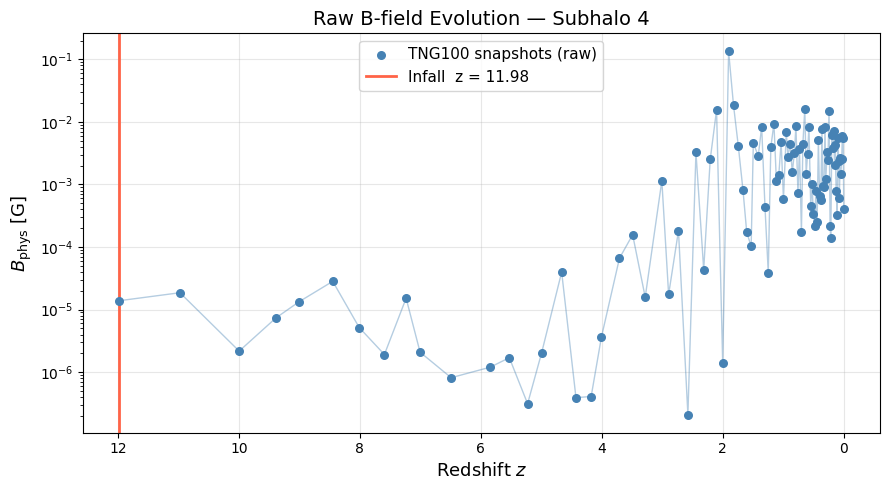

In [10]:
def plot_B_vs_redshift_single(mpb_records, infall_info=None, subhalo_id=None,
                              field='B_disk_phys'):
    """
    Plot raw B-field strength vs redshift for one galaxy's MPB.

    The x-axis is inverted so that time runs left to right
    (high redshift = early universe on the right; z=0 on the left).
    A vertical line marks the infall redshift if provided.

    Parameters
    ----------
    mpb_records  : list of dicts from get_mpb() + compute_B_physical()
    infall_info  : dict from find_infall_snap(), or None
    subhalo_id   : int, used for plot title and filename
    field        : str, which B-field to plot ('B_disk_phys' or 'B_halo_phys')
    """
    # Filter out invalid data points (zero or NaN B-field)
    valid  = [r for r in mpb_records if np.isfinite(r[field]) and r[field] > 0]
    z_arr  = np.array([r['redshift'] for r in valid])
    B_arr  = np.array([r[field]      for r in valid])
    # Sort by redshift so the line plot connects points in order
    order  = np.argsort(z_arr)
    z_arr, B_arr = z_arr[order], B_arr[order]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(z_arr, B_arr, s=30, color='steelblue', zorder=3, label='TNG100 snapshots (raw)')
    ax.plot(z_arr, B_arr, color='steelblue', alpha=0.4, lw=1)

    if infall_info:
        ax.axvline(infall_info['redshift'], color='tomato', lw=2,
                   label=f"Infall  z = {infall_info['redshift']:.2f}")

    ax.set_yscale('log')  # log scale because B spans several orders of magnitude
    ax.set_xlabel('Redshift $z$', fontsize=13)
    ax.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=13)
    ax.set_title(f'Raw B-field Evolution — Subhalo {subhalo_id}', fontsize=14)
    ax.invert_xaxis()  # put z=0 on the left (recent times on the left)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'B_vs_z_subhalo_{subhalo_id}.png', dpi=150)
    plt.show()


def plot_B_vs_redshift_all(all_galaxies, field='B_disk_phys'):
    """
    Overlay raw B-field vs redshift for all galaxies on one figure.

    Each galaxy's track is color-coded by its infall redshift using the plasma colormap.
    Dotted vertical lines mark each galaxy's individual infall redshift.
    This plot shows the diversity of evolutionary histories in the sample.

    Parameters
    ----------
    all_galaxies : list of dicts from process_all_satellites()
    field        : str, which B-field to plot
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Build color scale based on infall redshifts
    infalls = [g['infall']['redshift'] for g in all_galaxies if g['infall']]
    if not infalls:
        print('No galaxies with identified infall times found.')
        return
    norm = plt.Normalize(vmin=min(infalls), vmax=max(infalls))
    cmap = plt.cm.plasma

    for gal in all_galaxies:
        mpb    = gal['mpb']
        infall = gal['infall']
        valid  = [r for r in mpb if np.isfinite(r.get(field, np.nan)) and r[field] > 0]
        if not valid:
            continue
        z_arr = np.array([r['redshift'] for r in valid])
        B_arr = np.array([r[field]      for r in valid])
        order = np.argsort(z_arr)
        # Color by infall redshift; gray if no infall was identified
        color = cmap(norm(infall['redshift'])) if infall else 'gray'
        ax.plot(z_arr[order], B_arr[order], color=color, alpha=0.5, lw=1.2)
        if infall:
            ax.axvline(infall['redshift'], color=color, lw=0.5, ls=':', alpha=0.3)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Infall redshift $z_{\\rm infall}$')

    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=13)
    ax.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=13)
    ax.set_title(f'Raw B-field Evolution — All Satellites (N={len(all_galaxies)}, SubhaloGrNr=0)', fontsize=14)
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'B_vs_z_all_raw.png', dpi=150)  # fixed filename
    plt.show()


# Plot the single test galaxy to verify before running on all galaxies
plot_B_vs_redshift_single(mpb_data, infall_info=infall, subhalo_id=test_id)

---
## 7. Generalize to Multiple Galaxies

We now run the full pipeline (MPB download → B-field conversion → infall detection)
for all satellites in `satellites_z0`. Results are cached to a `.pkl` file at the repo root
so subsequent runs reload from disk without re-querying the API.

Galaxies that return a 403 error (no merger tree available) are automatically skipped.

In [11]:
def process_all_satellites(satellite_list):
    """
    Run the full data pipeline for every satellite in the list.

    For each satellite:
      1. Download its Main Progenitor Branch (MPB) via iapi.gettree()
      2. Convert comoving B-fields to physical Gauss
      3. Identify the infall snapshot (central → satellite transition)

    Satellites that fail to download (e.g., 403 Forbidden — no merger tree)
    are caught and skipped automatically.

    Parameters
    ----------
    satellite_list : list of dicts from query_satellites()

    Returns
    -------
    results : list of dicts, one per successful galaxy, each containing:
              {'subhalo_id': int, 'mpb': list, 'infall': dict or None}
    """
    results = []
    for i, gal in enumerate(satellite_list):
        sid = gal['id']
        print(f'[{i+1}/{len(satellite_list)}] SubhaloID {sid} ...', end=' ')
        try:
            mpb    = get_mpb(sid)             # download merger tree
            mpb    = compute_B_physical(mpb)  # convert to physical B-field
            infall = find_infall_snap(mpb)    # detect infall snapshot
            results.append({'subhalo_id': sid, 'mpb': mpb, 'infall': infall})
            status = f"infall z={infall['redshift']:.2f}" if infall else 'no infall found'
            print(f'OK ({status})')
        except Exception as e:
            print(f'SKIPPED: {e}')  # print error but continue to next galaxy
    print(f'\nProcessed  : {len(results)} galaxies')
    print(f'With infall: {sum(1 for g in results if g["infall"])}')
    return results


# Load from cache if it exists, otherwise download fresh
# Delete the .pkl file if you want to force a fresh download
cache = DATA_DIR / 'all_galaxies_grnr0.pkl'
if os.path.exists(cache):
    with open(cache, 'rb') as f:
        all_galaxies = pickle.load(f)
    print(f'Loaded {len(all_galaxies)} galaxies from cache: {cache}')
else:
    all_galaxies = process_all_satellites(satellites_z0)
    with open(cache, 'wb') as f:
        pickle.dump(all_galaxies, f)
    print(f'Saved {len(all_galaxies)} galaxies to cache: {cache}')

Loaded 50 galaxies from cache: /workspaces/Numerical_methods_Project/data/processed/all_galaxies_grnr0.pkl


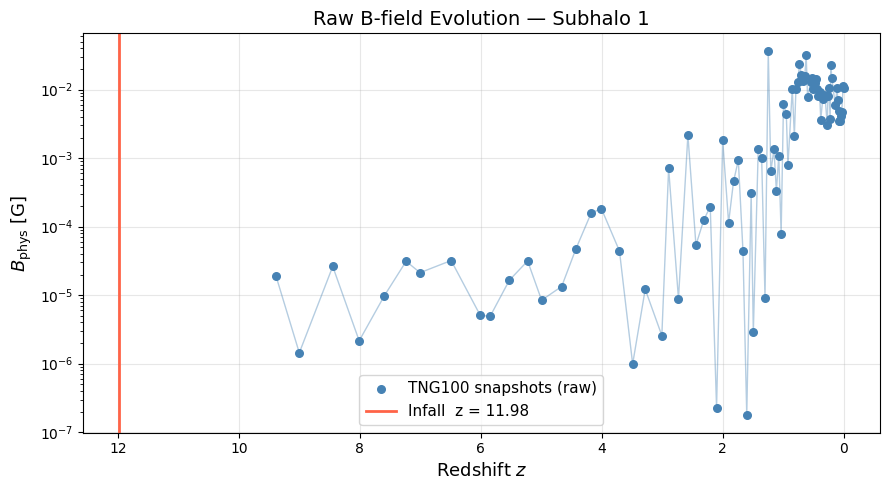

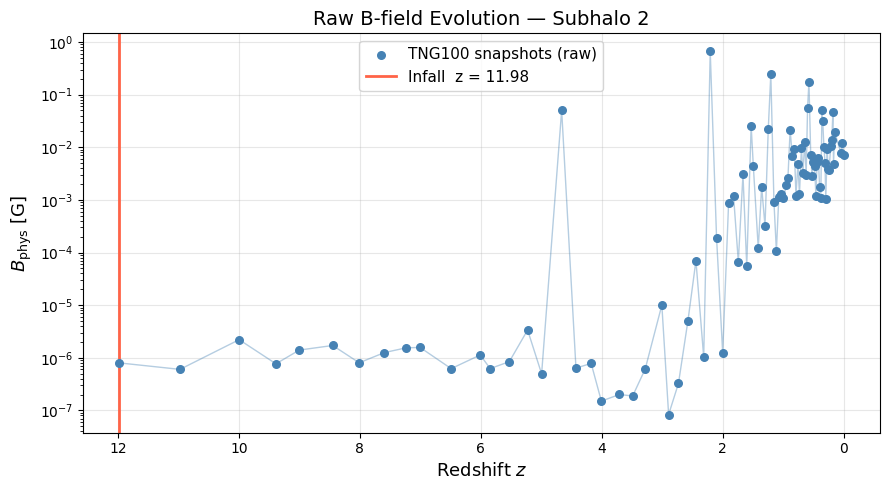

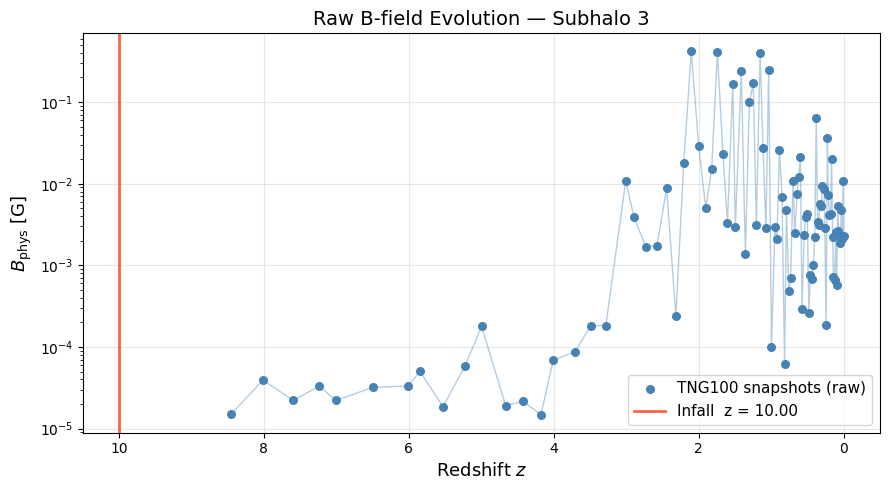

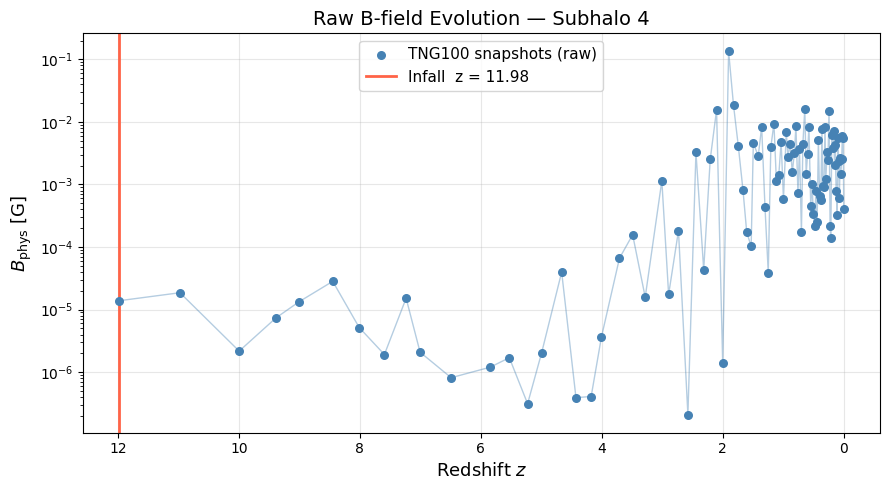

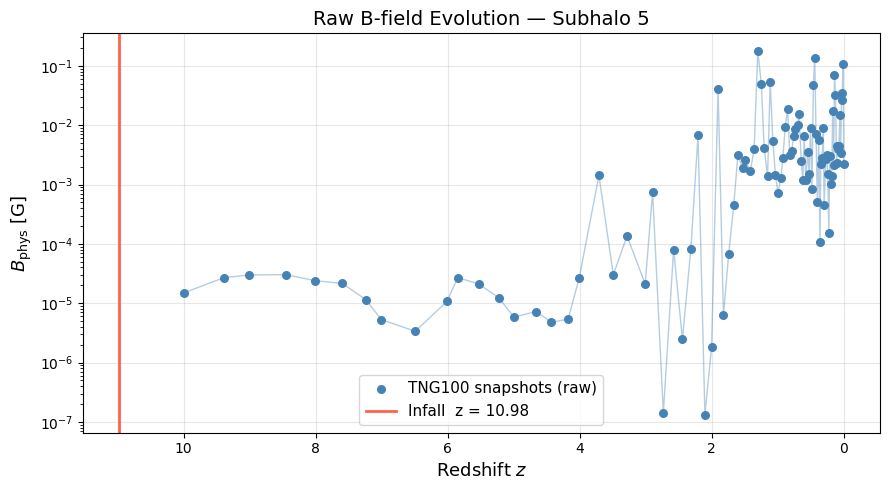

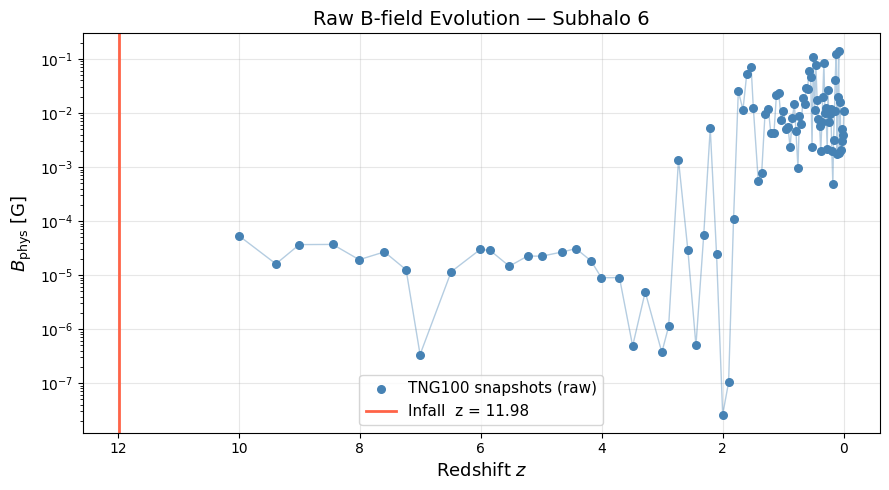

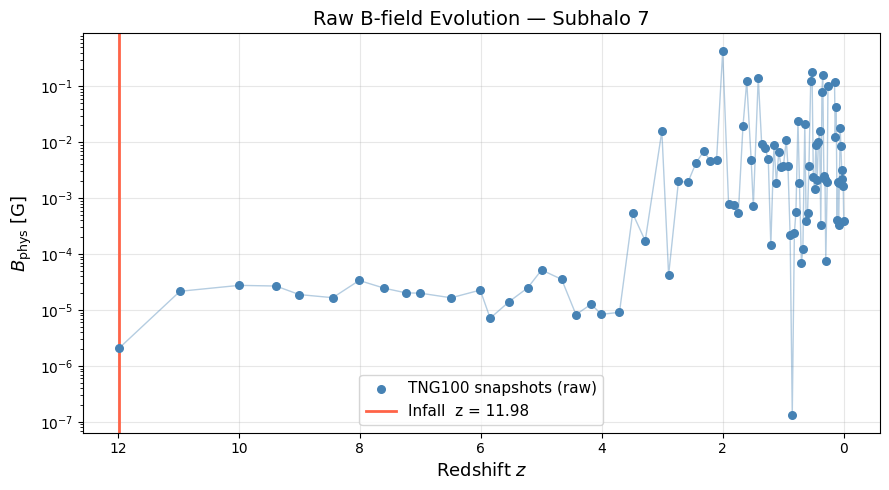

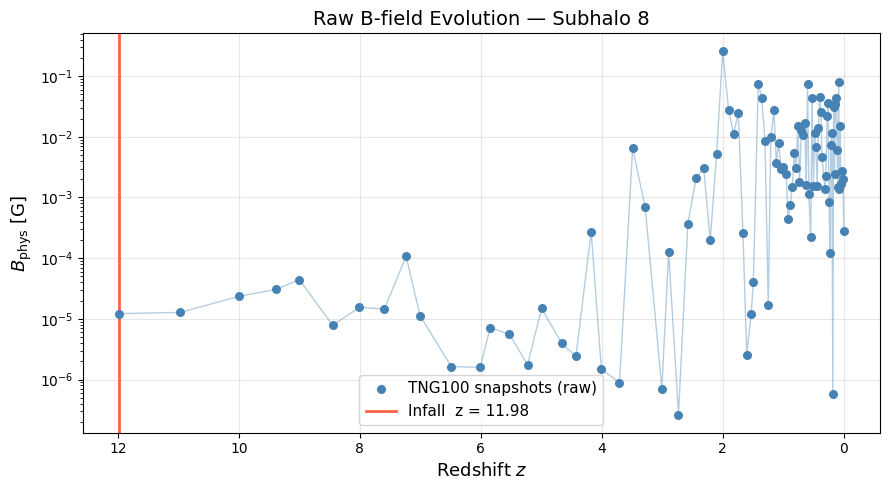

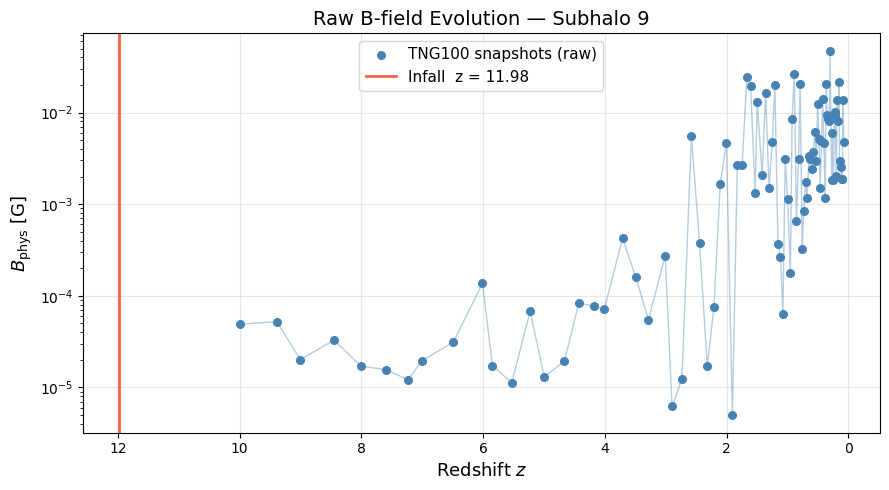

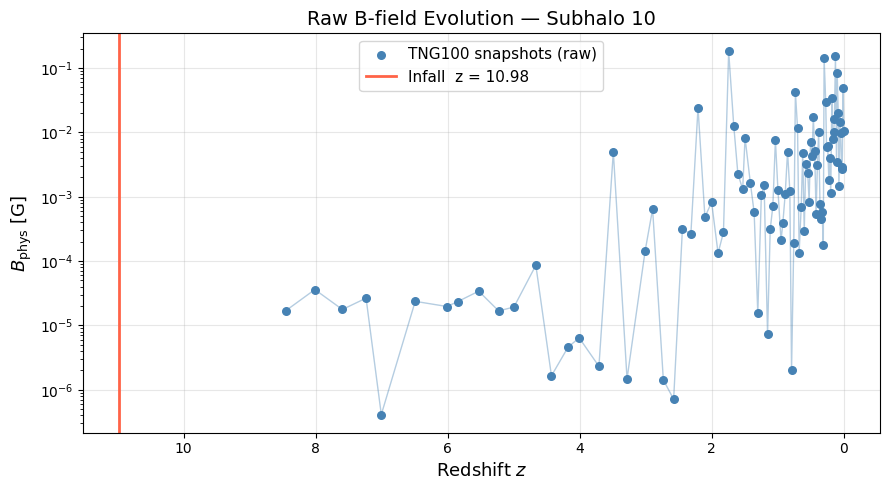

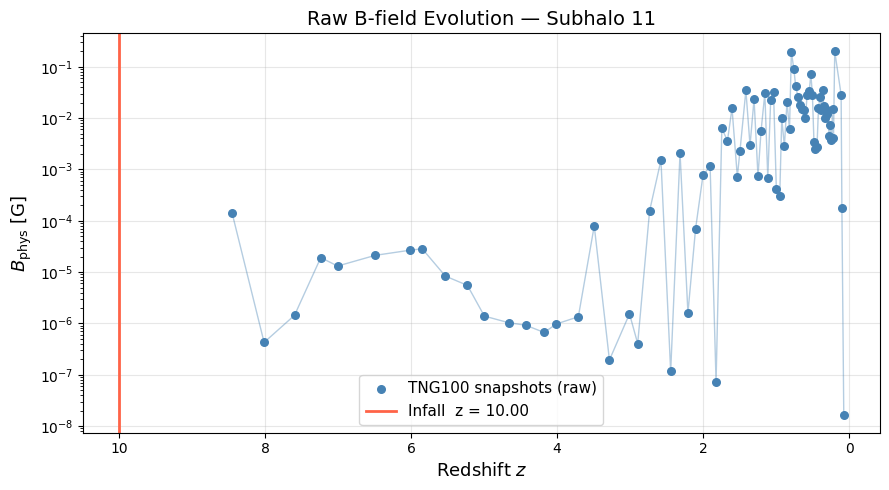

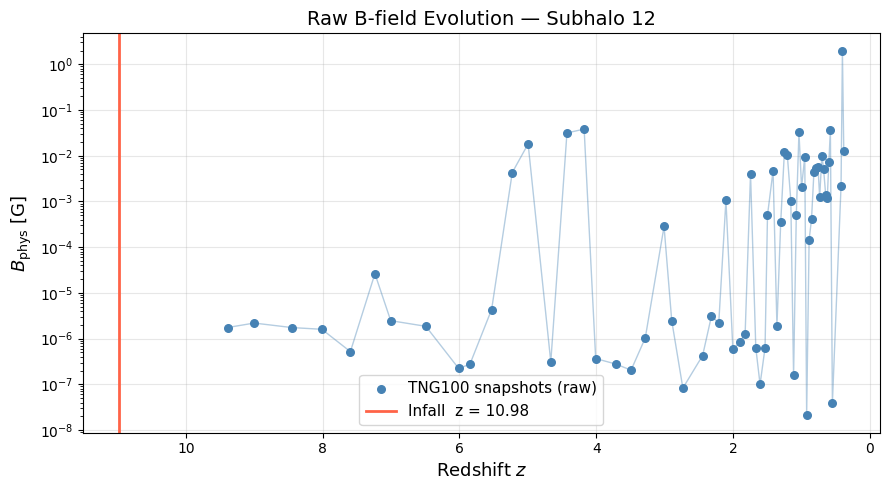

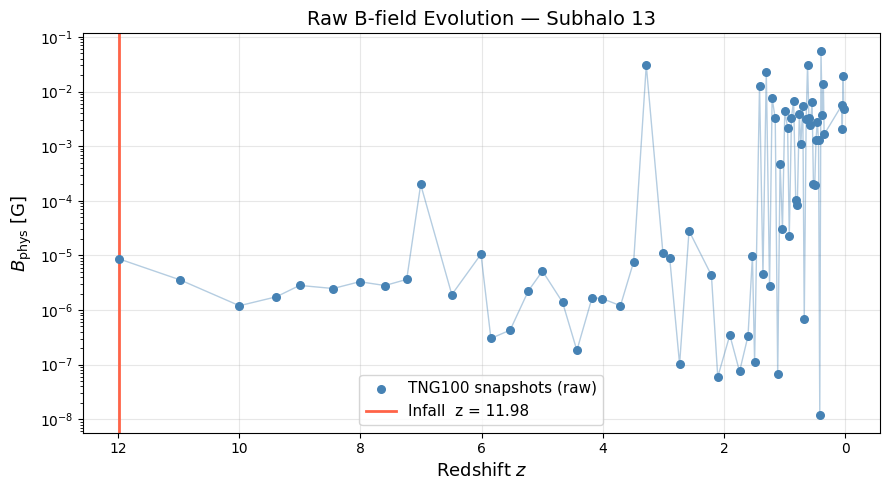

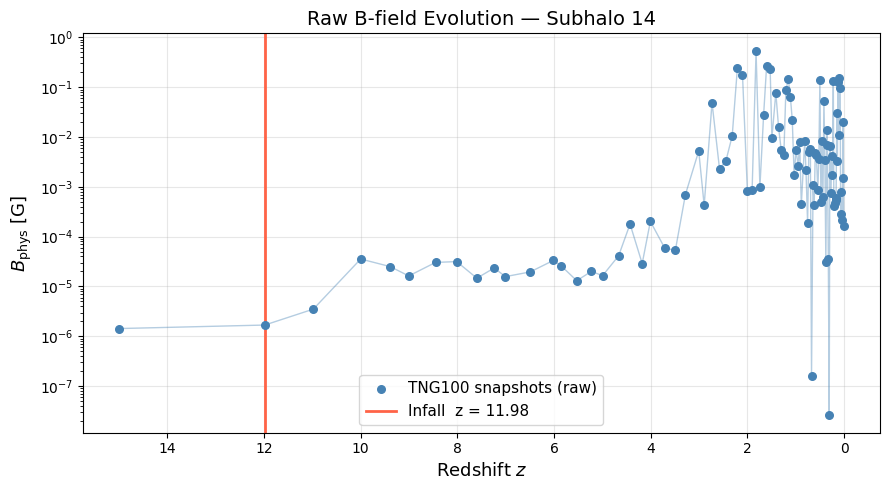

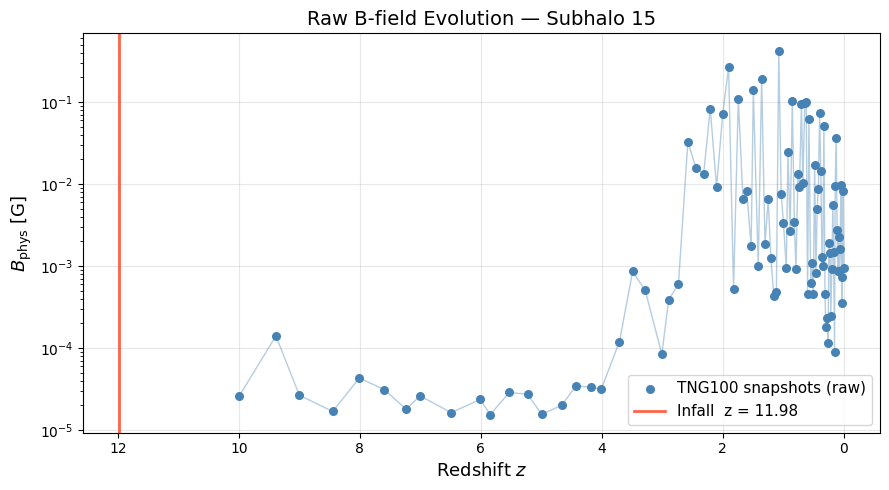

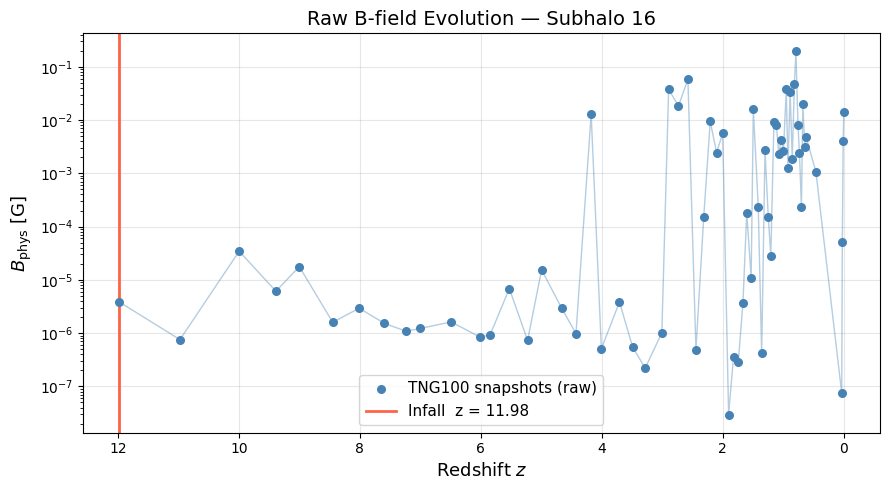

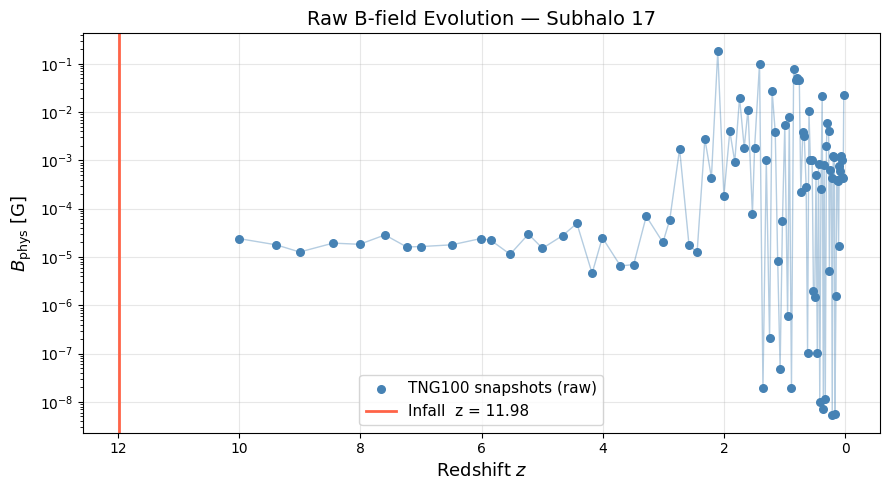

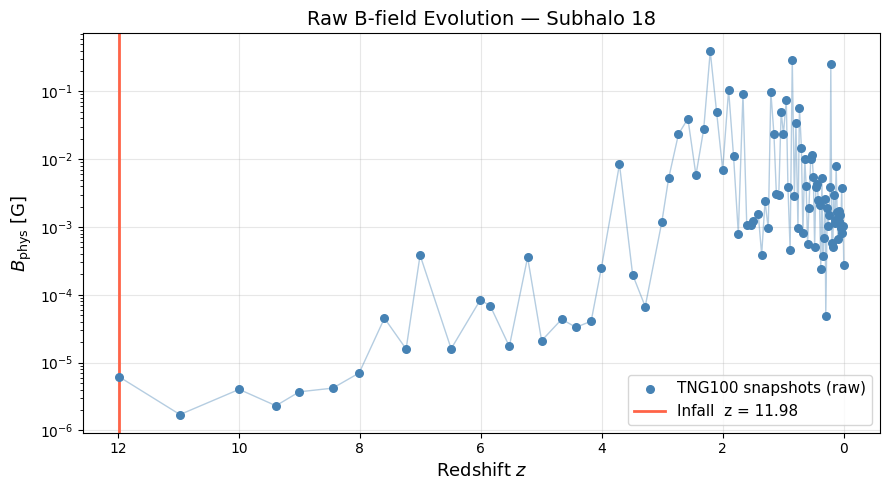

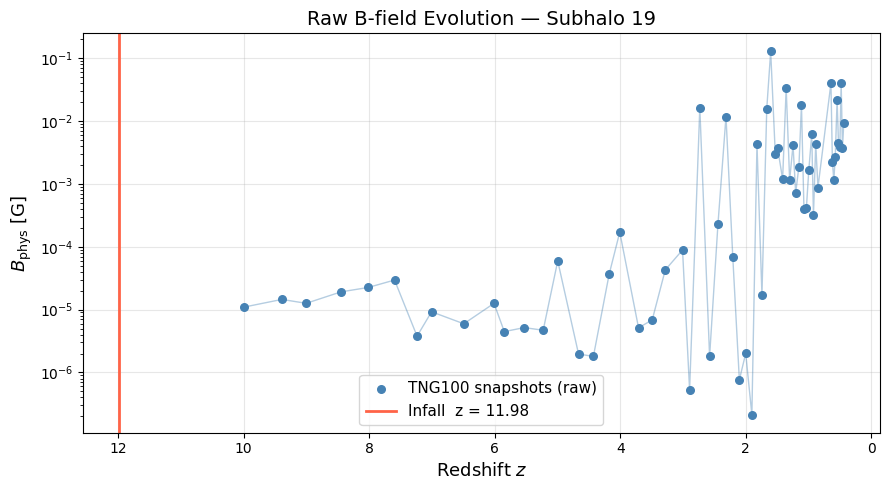

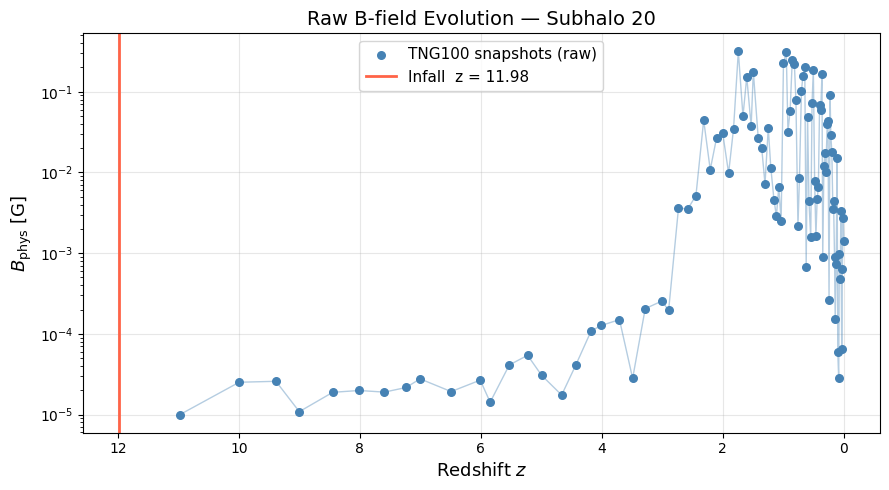

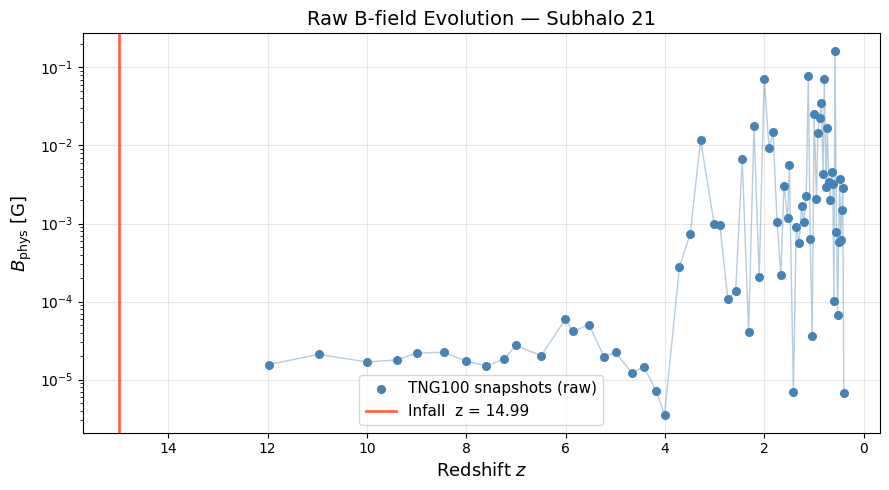

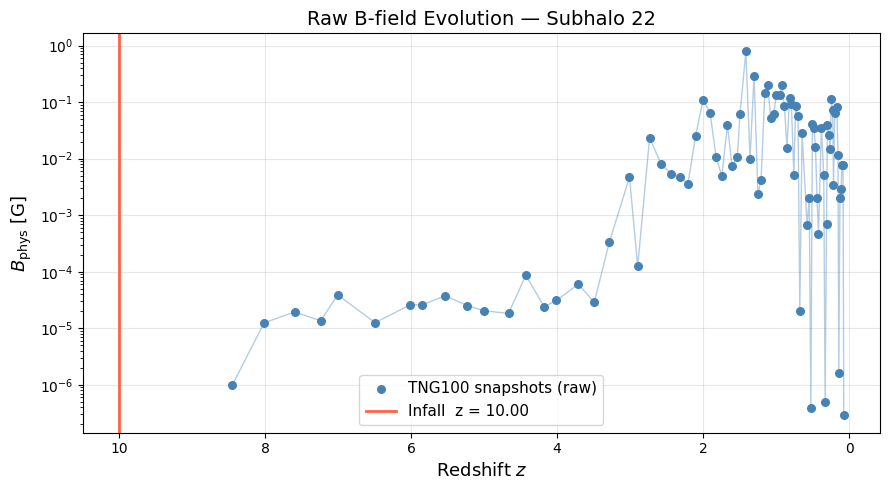

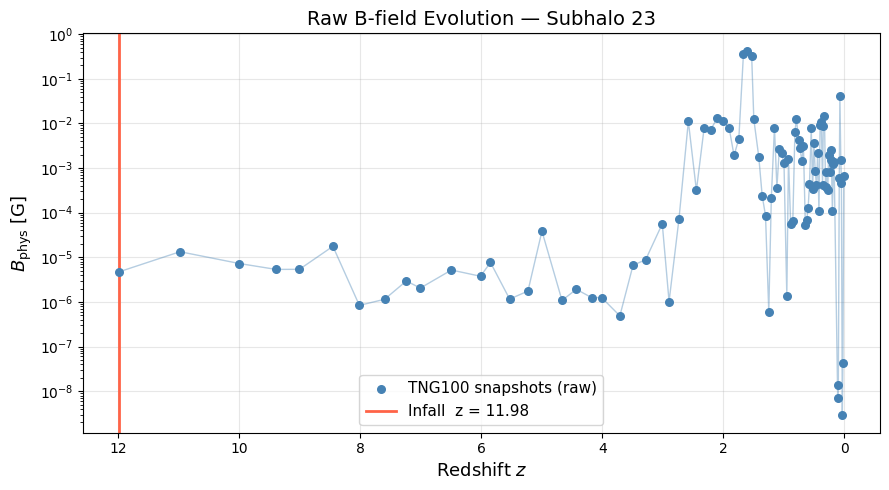

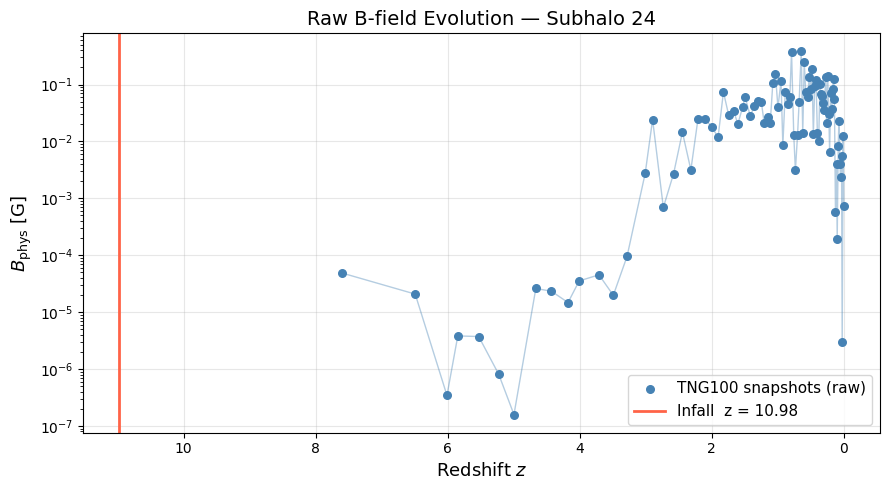

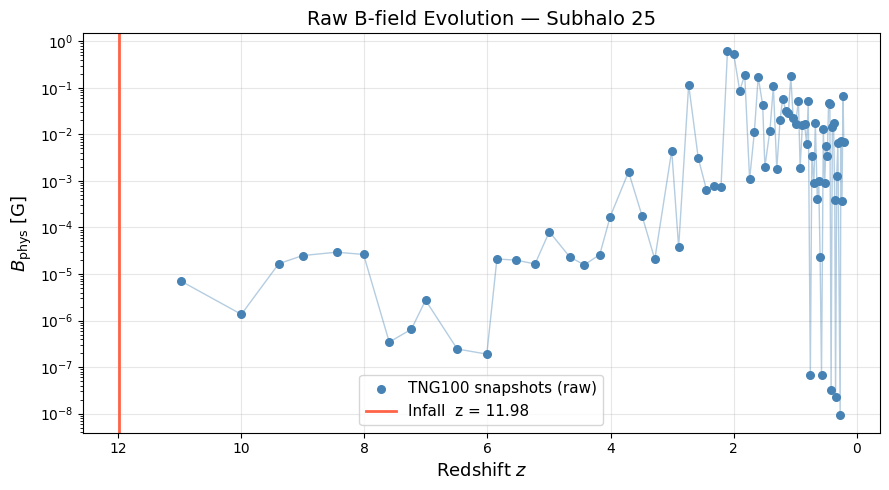

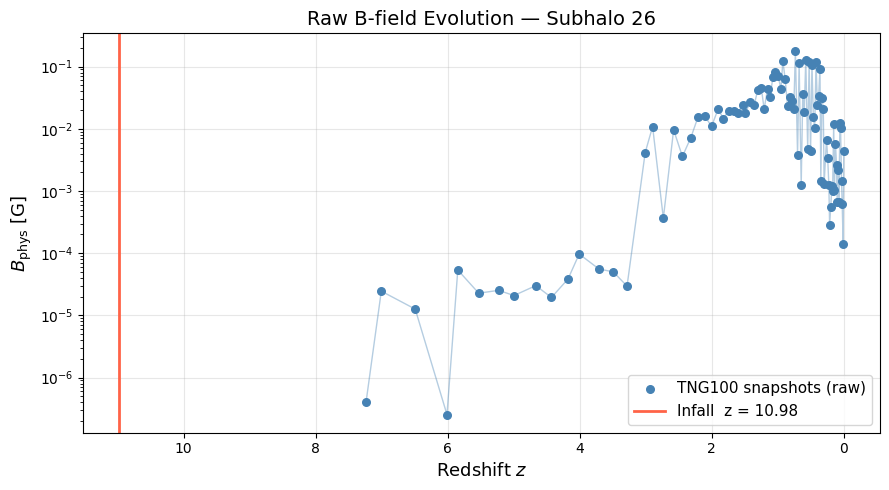

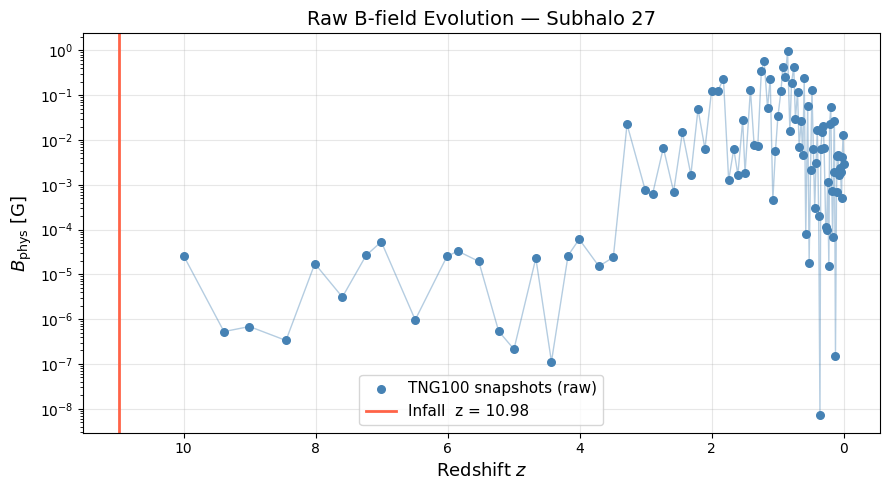

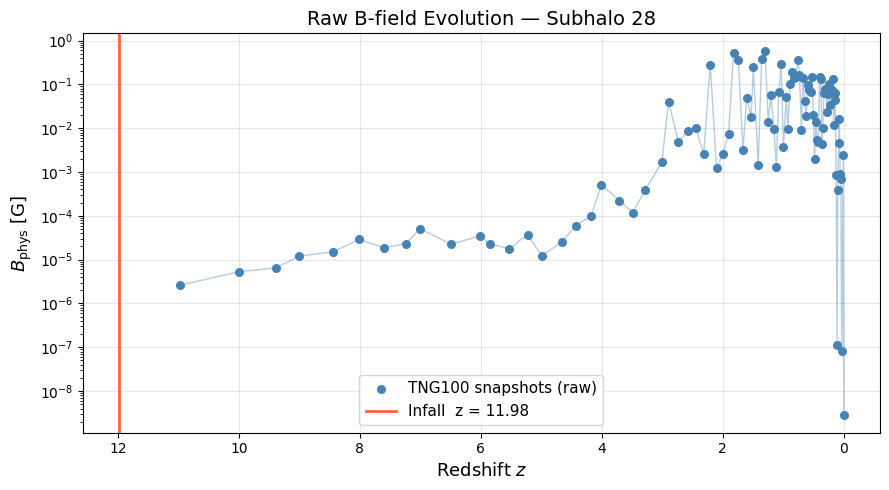

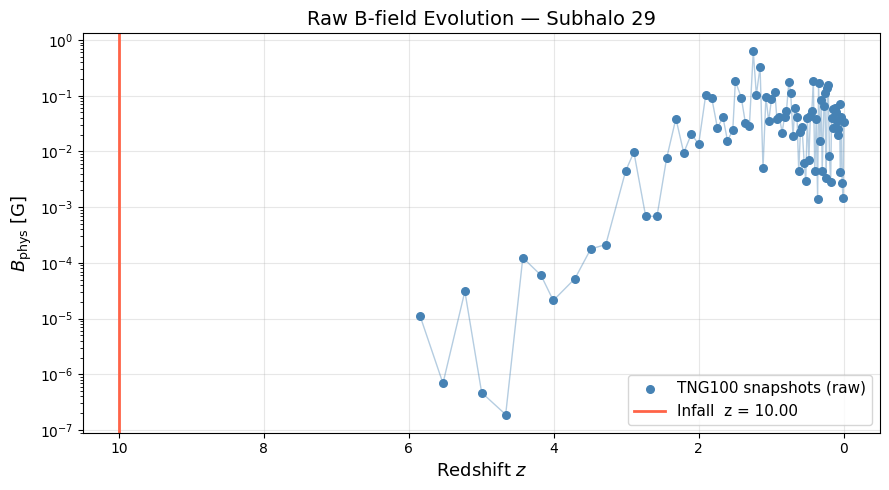

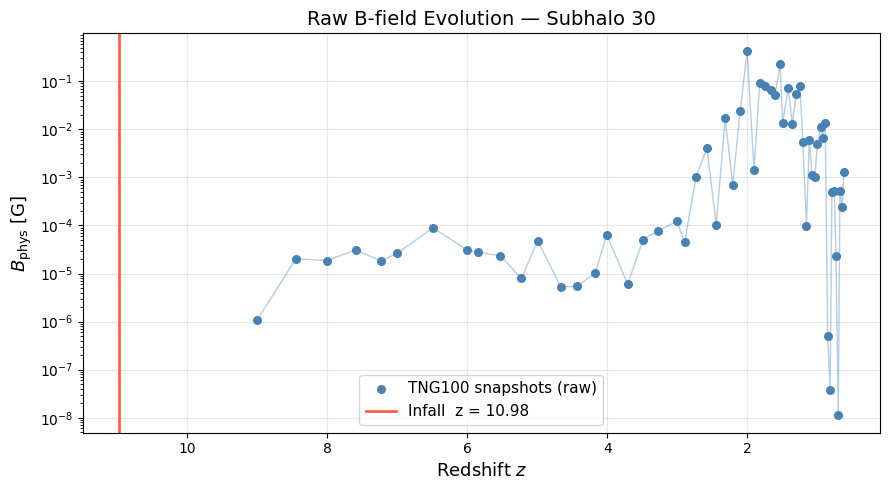

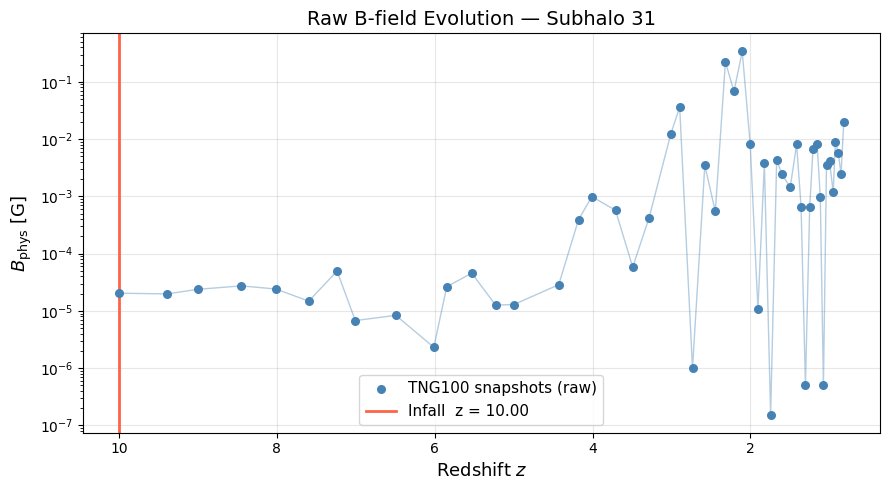

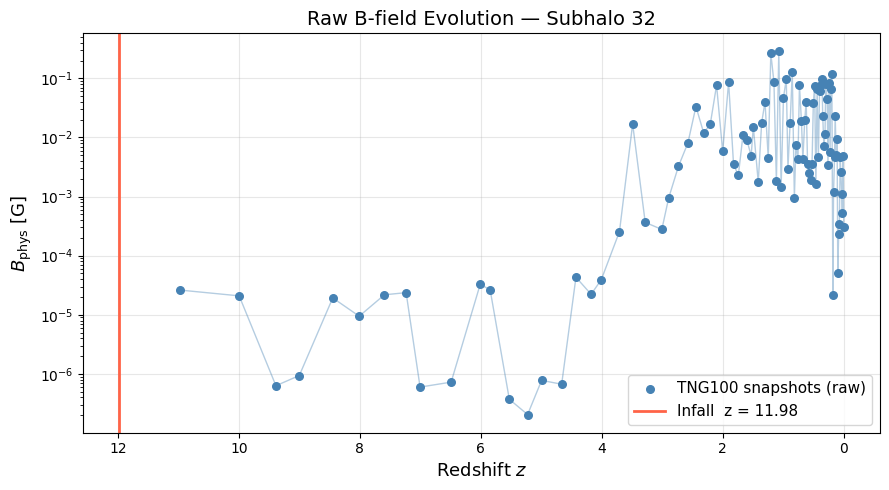

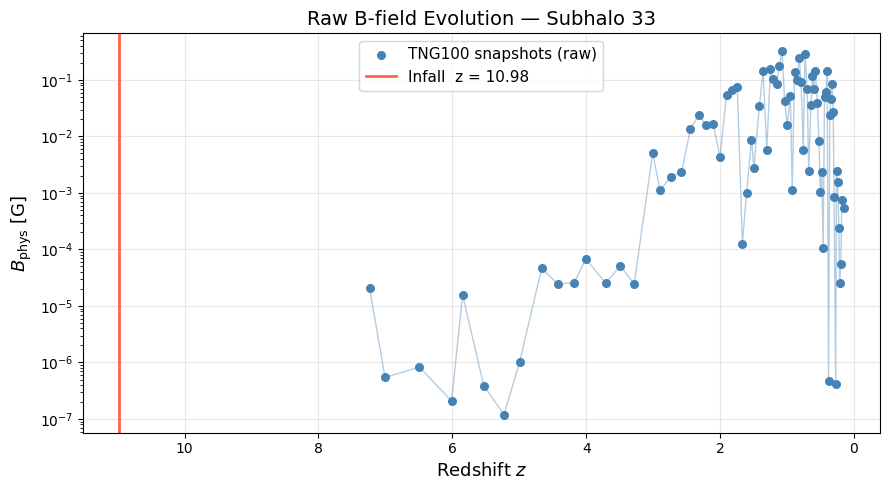

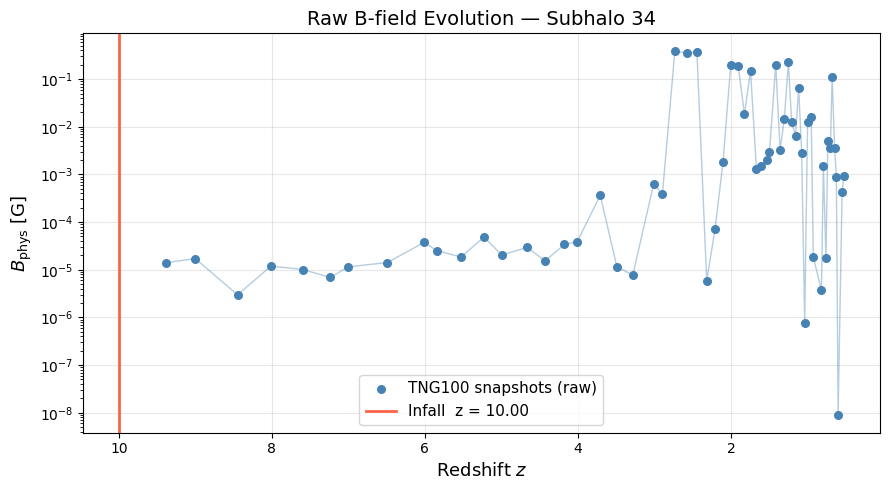

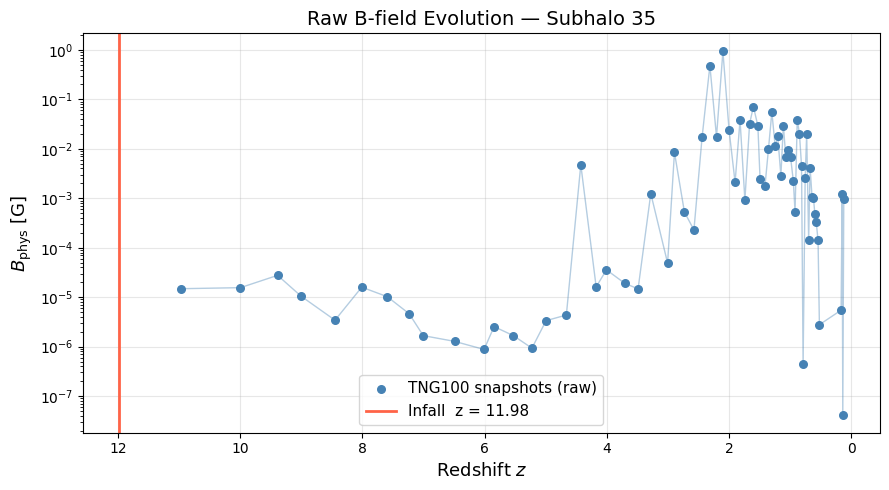

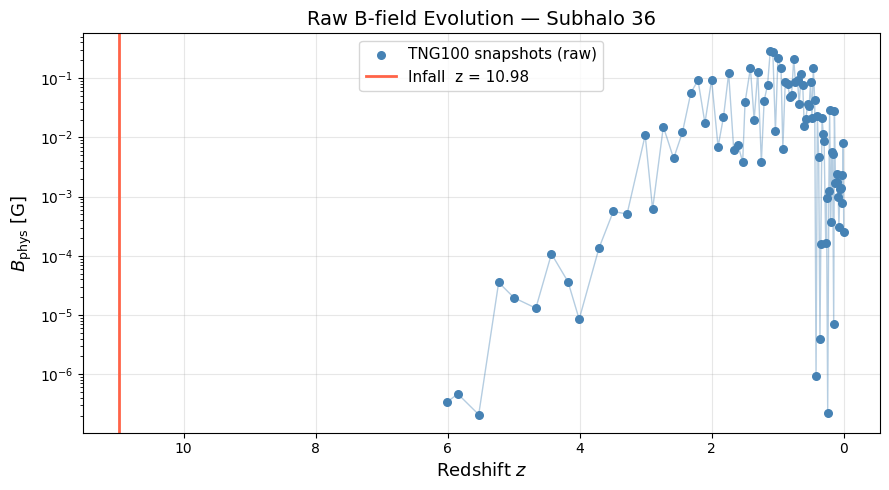

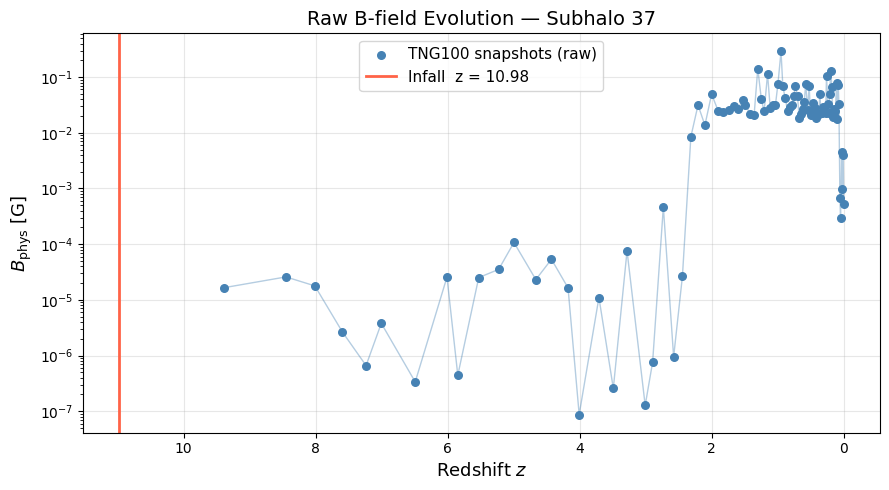

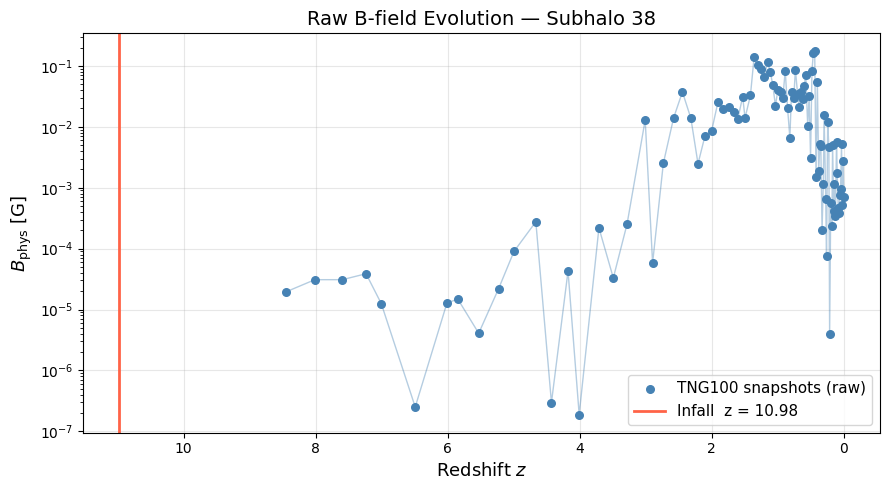

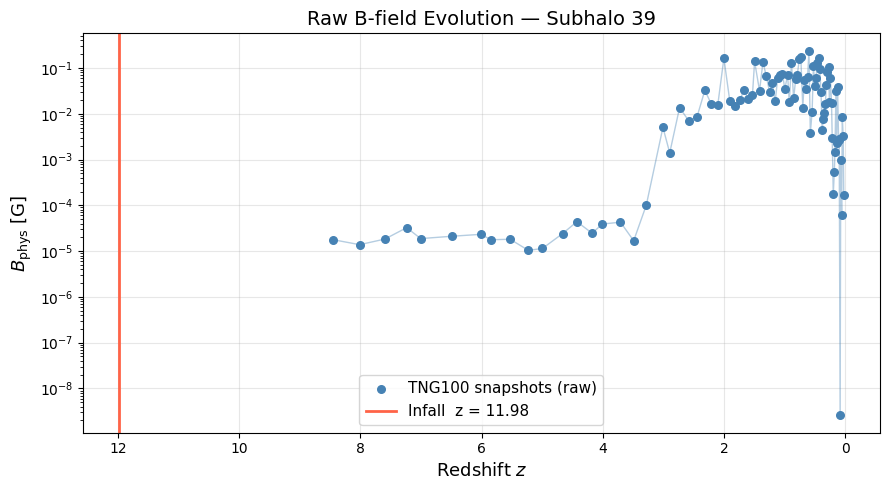

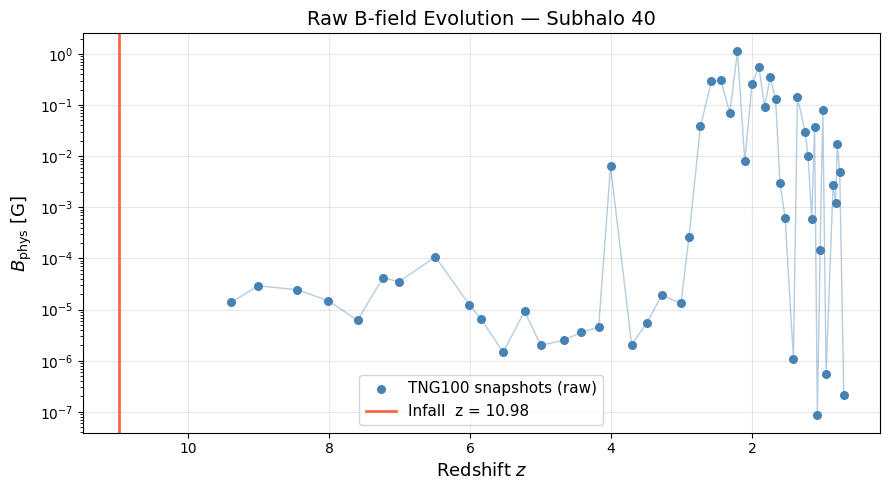

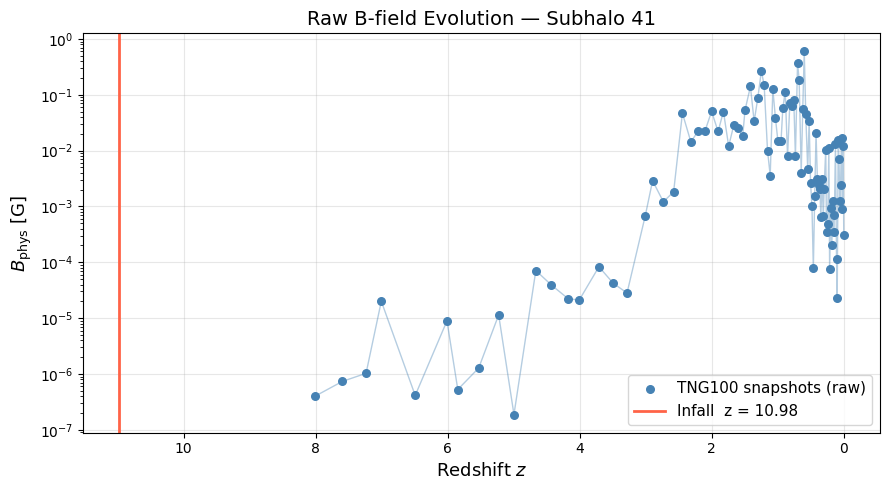

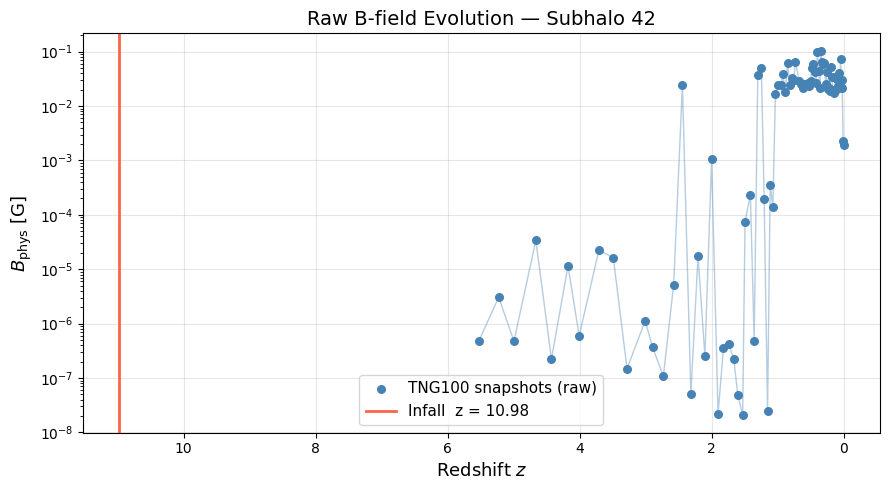

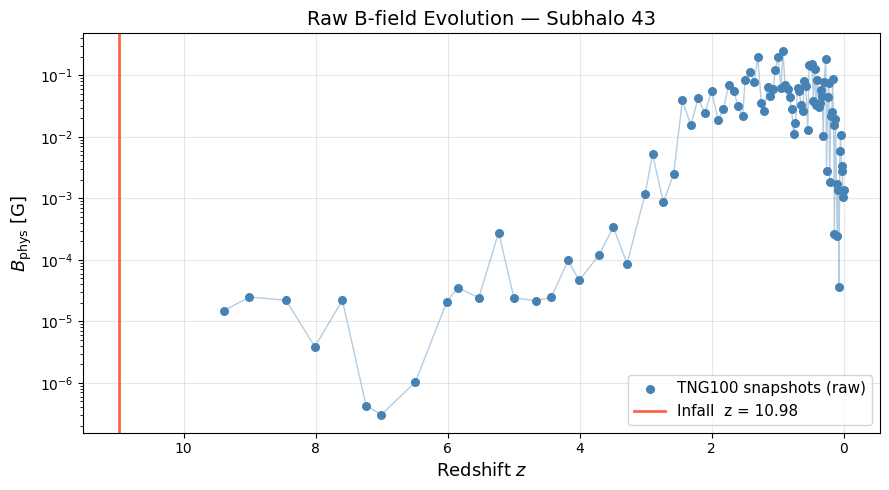

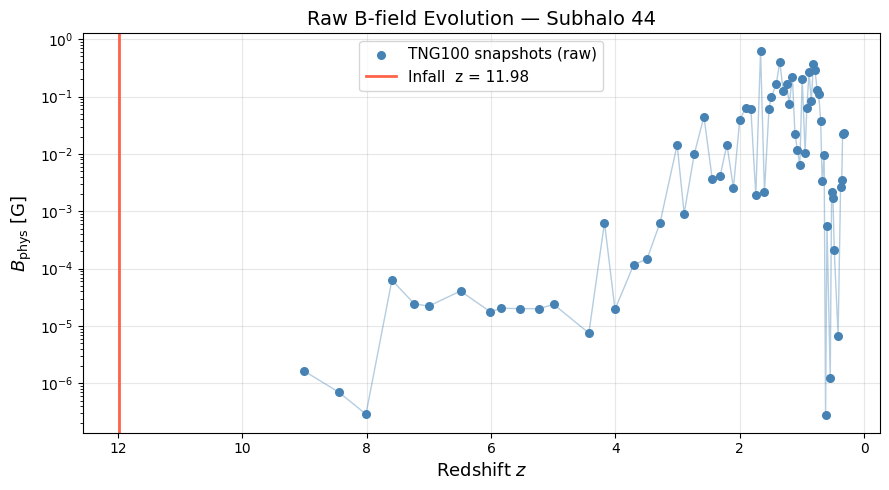

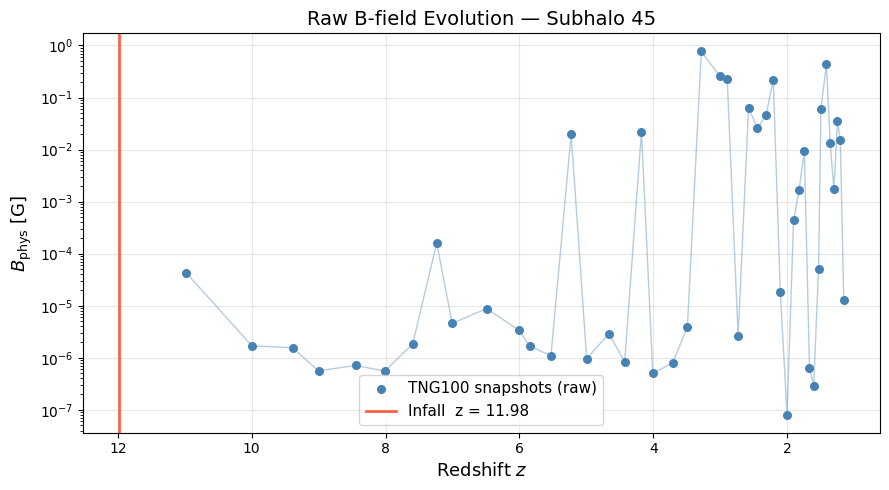

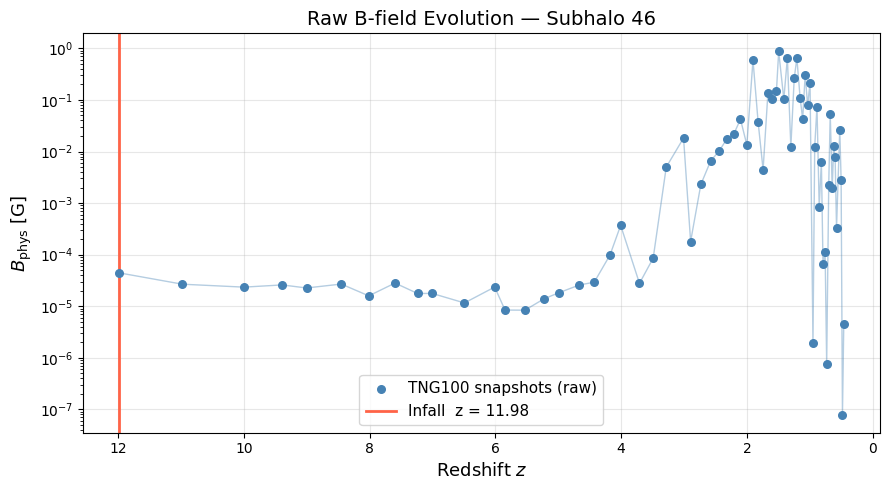

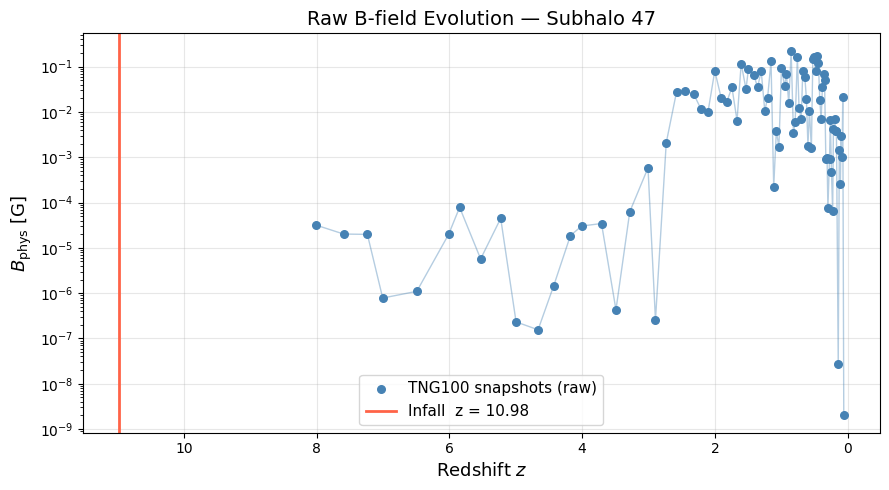

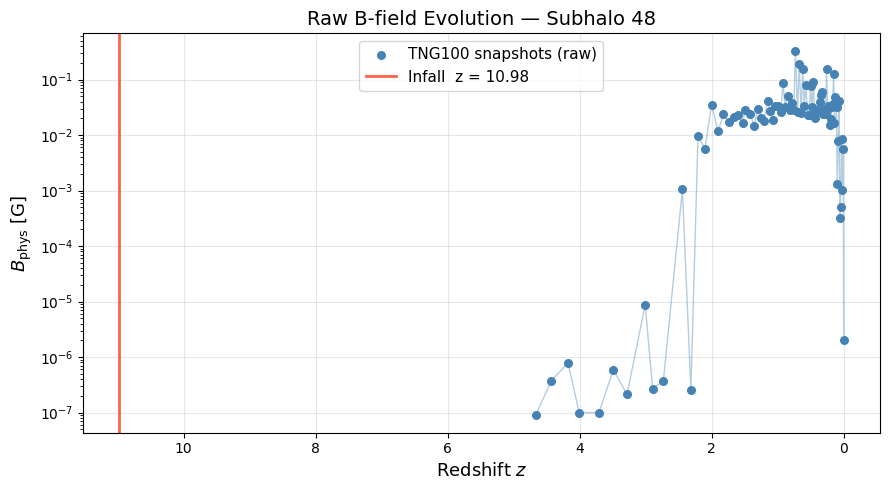

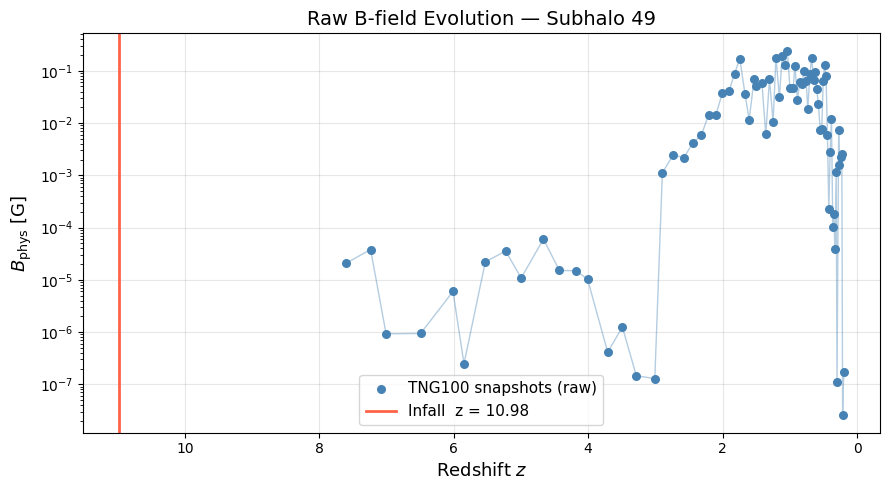

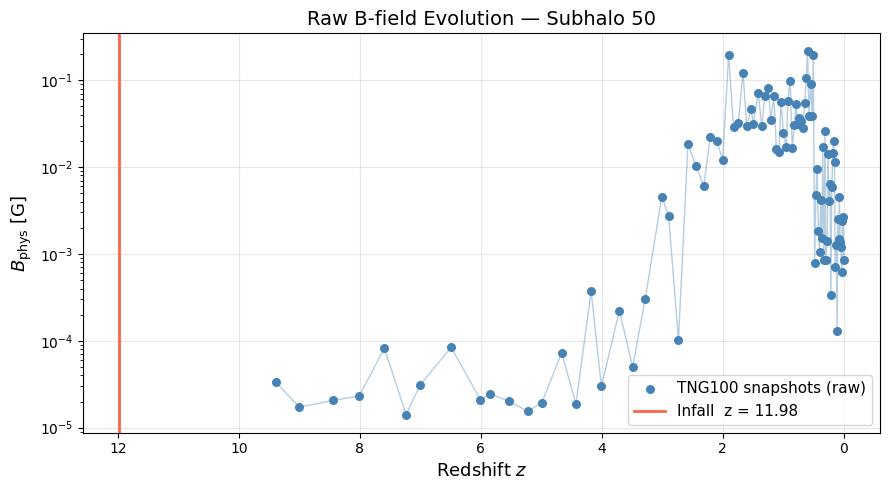

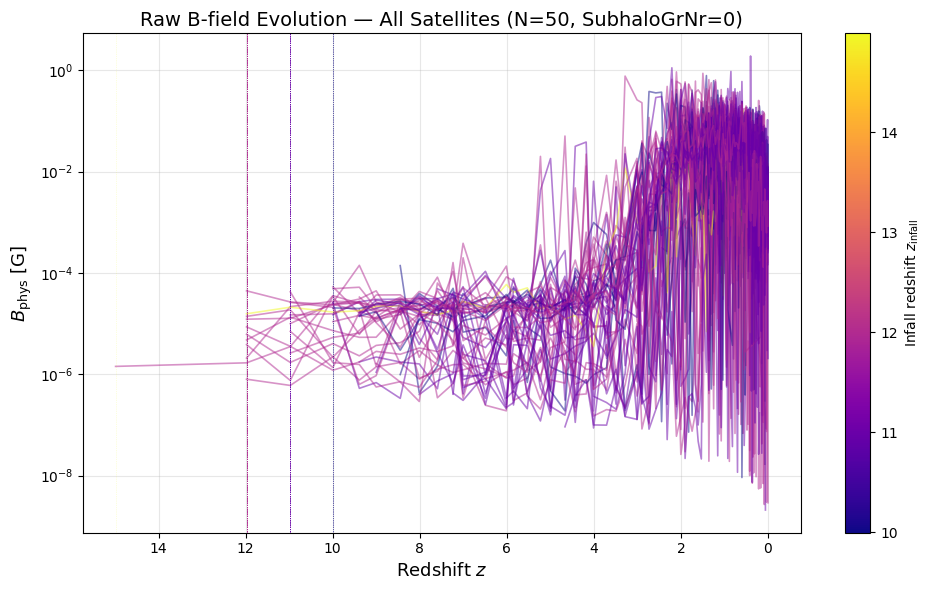

In [12]:
# Plot raw B-field vs redshift for every galaxy individually
for gal in all_galaxies:
    plot_B_vs_redshift_single(
        gal['mpb'],
        infall_info=gal['infall'],
        subhalo_id=gal['subhalo_id']
    )

# Also plot all galaxies overlaid on one figure for comparison
plot_B_vs_redshift_all(all_galaxies)

---
## 8. Kernel Smoothing + LOOCV Bandwidth Selection

The raw B-field time series is noisy and the TNG snapshots are **not uniformly spaced** in lookback time,
so a standard moving average is inappropriate (it assumes equal spacing between data points).

We instead use a **Gaussian kernel smoother** (Nadaraya-Watson estimator), which computes a
weighted average of all observed B-field values, where the weight decreases with distance in time:

$$\hat{B}(t) = \frac{\sum_i K_h(t - t_i)\, B_i}{\sum_i K_h(t - t_i)}, \qquad K_h(u) = \exp\!\left(-\frac{u^2}{2h^2}\right)$$

The bandwidth $h$ (in Gyr) controls how wide the smoothing window is.
Too small → follows noise; too large → erases real features.

We select the optimal $h^*$ per galaxy using **leave-one-out cross-validation (LOOCV)**:
for each data point $j$, we fit the smoother on all *other* points and measure the prediction error at $t_j$.
The bandwidth that minimizes the average prediction error is chosen:

$$\text{CV}(h) = \frac{1}{n}\sum_{j=1}^{n}\left(B_j - \hat{B}_{(-j)}(t_j)\right)^2, \qquad h^* = \arg\min_h\,\text{CV}(h)$$

Smoothing is done in **log10(B) space** to handle the large dynamic range of B-field values,
then converted back to linear space for plotting.

In [13]:
def gaussian_kernel(u, h):
    """
    Evaluate the Gaussian kernel at distance u with bandwidth h.

    K_h(u) = exp(-u^2 / 2h^2)

    Large h -> kernel is wide -> more smoothing.
    Small h -> kernel is narrow -> less smoothing, follows data more closely.
    """
    return np.exp(-0.5 * (u / h)**2)


def kernel_smooth(t_query, t_obs, B_obs, h, exclude_idx=None):
    """
    Nadaraya-Watson kernel smoother: compute B-hat at one or more query times.

    For each query time t, computes a weighted average of all observations:
        B_hat(t) = sum(w_i * B_i) / sum(w_i)
    where w_i = K_h(t - t_i) is the Gaussian kernel weight.

    Parameters
    ----------
    t_query     : float or array, query time(s) in Gyr
    t_obs       : array, observed lookback times (Gyr)
    B_obs       : array, observed B-field values (in log10 space)
    h           : float, bandwidth in Gyr
    exclude_idx : int or None, index to leave out (used for LOOCV)

    Returns
    -------
    B_hat : float or array, smoothed estimate at t_query
    """
    # Build a boolean mask — if exclude_idx is set, that point is left out
    mask = np.ones(len(t_obs), dtype=bool)
    if exclude_idx is not None:
        mask[exclude_idx] = False
    t_use = t_obs[mask]
    B_use = B_obs[mask]

    t_query  = np.atleast_1d(np.asarray(t_query, dtype=float))
    B_hat    = np.zeros(len(t_query))
    for k, tq in enumerate(t_query):
        weights  = gaussian_kernel(tq - t_use, h)  # weight each observation by distance
        w_sum    = weights.sum()
        # Guard against zero total weight (can happen if h is very small)
        B_hat[k] = (weights @ B_use) / w_sum if w_sum > 1e-30 else np.nan

    return B_hat if len(B_hat) > 1 else float(B_hat[0])


def loocv_score(h, t_obs, B_obs):
    """
    Compute the leave-one-out cross-validation (LOOCV) score for bandwidth h.

    For each observation j:
      1. Fit the smoother using all points EXCEPT j
      2. Predict B at time t_j using the leave-one-out smoother
      3. Record the squared error (B_j - B_hat_(-j))^2

    The LOOCV score is the mean squared error across all left-out points.
    A bandwidth that generalizes well (neither overfit nor underfit) will
    have a low LOOCV score.

    Parameters
    ----------
    h     : float, candidate bandwidth in Gyr
    t_obs : array, lookback times (Gyr)
    B_obs : array, B-field values (log10 space)

    Returns
    -------
    cv_mse : float, mean squared LOOCV error
    """
    n      = len(t_obs)
    errors = np.zeros(n)
    for j in range(n):
        B_pred    = kernel_smooth(t_obs[j], t_obs, B_obs, h, exclude_idx=j)
        errors[j] = (B_obs[j] - B_pred)**2
    return errors.mean()


def select_bandwidth(t_obs, B_obs, h_grid=None):
    """
    Find the optimal bandwidth h* by minimizing LOOCV score over a grid.

    Evaluates CV(h) for each candidate bandwidth in h_grid and returns
    the h value with the lowest cross-validation error.

    Parameters
    ----------
    t_obs  : array, lookback times (Gyr)
    B_obs  : array, B-field values (log10 space)
    h_grid : array or None, candidate bandwidths in Gyr
             Default: 50 values from 0.05 to 2.0 Gyr

    Returns
    -------
    h_opt     : float, optimal bandwidth
    h_grid    : array, the candidate bandwidths that were tested
    cv_scores : array, LOOCV MSE at each candidate bandwidth
    """
    if h_grid is None:
        # Finer grid with smaller minimum to allow tighter fits near infall
        h_grid = np.linspace(0.05, 2.0, 200)
    cv_scores = np.array([loocv_score(h, t_obs, B_obs) for h in h_grid])
    h_opt     = h_grid[np.argmin(cv_scores)]  # pick the h with lowest CV error
    return h_opt, h_grid, cv_scores


def smooth_galaxy(mpb_records, infall_info, field='B_disk_phys', h_grid=None):
    """
    Apply kernel smoothing with LOOCV bandwidth selection to one galaxy's B-field history.

    All operations are performed in lookback time (Gyr), not redshift.
    Smoothing is done in log10(B) space to handle the large dynamic range,
    then converted back to linear space for the output.

    The time coordinate relative to infall is computed as:
        dt = t_infall - t_lb
    so that dt > 0 is after infall (time increases to the right in plots).

    Parameters
    ----------
    mpb_records  : list of dicts from get_mpb() + compute_B_physical()
    infall_info  : dict from find_infall_snap(), or None
    field        : str, which B-field to smooth ('B_disk_phys' or 'B_halo_phys')
    h_grid       : array or None, candidate bandwidths for LOOCV

    Returns
    -------
    result : dict with keys:
             t_obs, B_obs (raw data, linear space)
             t_fine, B_smooth (smoothed curve on fine grid, linear space)
             h_opt, h_grid, cv_scores (LOOCV results)
             t_infall, dt_obs, dt_fine (if infall_info provided)
    None if fewer than 5 valid data points
    """
    # Filter to valid (positive, finite) B-field values
    valid = [r for r in mpb_records
             if np.isfinite(r.get(field, np.nan)) and r[field] > 0
             and np.isfinite(r['lookback_time'])]
    if len(valid) < 5:
        return None  # not enough data points for meaningful smoothing

    t_obs = np.array([r['lookback_time'] for r in valid])
    # Smooth in log10 space — handles the large dynamic range of B-field values
    B_obs = np.log10(np.array([r[field] for r in valid]))
    # Sort by lookback time (ascending) for consistent processing
    order = np.argsort(t_obs)
    t_obs, B_obs = t_obs[order], B_obs[order]

    # Select optimal bandwidth via LOOCV
    h_opt, h_grid_out, cv_scores = select_bandwidth(t_obs, B_obs, h_grid)

    # Evaluate the smoother on a fine uniform time grid (300 points)
    t_fine   = np.linspace(t_obs.min(), t_obs.max(), 300)
    B_smooth = kernel_smooth(t_fine, t_obs, B_obs, h_opt)

    # Convert back from log10 to linear space for plotting
    result = {
        't_obs'     : t_obs,
        'B_obs'     : 10**B_obs,       # back to linear Gauss
        'h_opt'     : h_opt,
        'h_grid'    : h_grid_out,
        'cv_scores' : cv_scores,
        't_fine'    : t_fine,
        'B_smooth'  : 10**B_smooth,    # back to linear Gauss
    }

    # Add infall-relative time axis if infall time is known
    if infall_info:
        t_inf               = infall_info['lookback_time']
        result['t_infall']  = t_inf
        # dt > 0 means after infall; dt < 0 means before infall
        result['dt_obs']    = t_inf - t_obs
        result['dt_fine']   = t_inf - t_fine
    return result


print('Kernel smoothing functions defined.')

Kernel smoothing functions defined.


Optimal bandwidth : h* = 0.863 Gyr


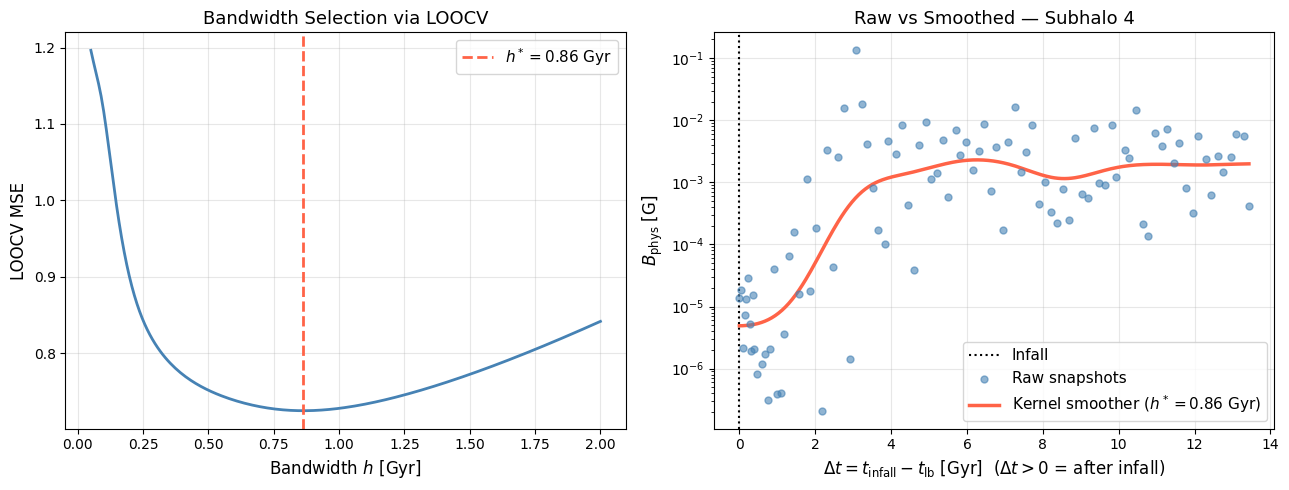

In [14]:
def plot_smoothing_diagnostics(smooth_result, subhalo_id=None):
    """
    Two-panel diagnostic plot for a single galaxy's kernel smoothing result.

    Left panel : LOOCV score vs bandwidth h
                 The minimum (marked with dashed line) is the optimal h*.
                 A clear minimum shows the smoother is well-constrained.

    Right panel: Raw snapshot data vs kernel smoother at optimal h*
                 Time axis is Delta_t relative to infall (if infall is known).
                 This panel lets you visually verify the smoother is fitting well.

    Parameters
    ----------
    smooth_result : dict from smooth_galaxy(), or None (skips if None)
    subhalo_id    : int, used for title and filename
    """
    if smooth_result is None:
        return  # nothing to plot if smoothing failed

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: LOOCV score vs bandwidth ───────────────────────────────────────
    ax1.plot(smooth_result['h_grid'], smooth_result['cv_scores'],
             color='steelblue', lw=2)
    ax1.axvline(smooth_result['h_opt'], color='tomato', lw=2, ls='--',
                label=f"$h^* = {smooth_result['h_opt']:.2f}$ Gyr")
    ax1.set_xlabel('Bandwidth $h$ [Gyr]', fontsize=12)
    ax1.set_ylabel('LOOCV MSE', fontsize=12)
    ax1.set_title('Bandwidth Selection via LOOCV', fontsize=13)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # ── Right: raw data vs smoothed curve ────────────────────────────────────
    # Use Delta_t axis if infall is known; otherwise use raw lookback time
    if 'dt_obs' in smooth_result:
        x_obs  = smooth_result['dt_obs']
        x_fine = smooth_result['dt_fine']
        xlabel = r'$\Delta t = t_{\rm infall} - t_{\rm lb}$ [Gyr]  ($\Delta t > 0$ = after infall)'
        ax2.axvline(0, color='black', lw=1.5, ls=':', label='Infall')
    else:
        x_obs  = smooth_result['t_obs']
        x_fine = smooth_result['t_fine']
        xlabel = 'Lookback time [Gyr]'

    ax2.scatter(x_obs, smooth_result['B_obs'], s=25,
                color='steelblue', alpha=0.6, zorder=3, label='Raw snapshots')
    ax2.plot(x_fine, smooth_result['B_smooth'], color='tomato', lw=2.5,
             label=f"Kernel smoother ($h^*={smooth_result['h_opt']:.2f}$ Gyr)")
    ax2.set_yscale('log')
    ax2.set_xlabel(xlabel, fontsize=12)
    ax2.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=12)
    ax2.set_title(f'Raw vs Smoothed — Subhalo {subhalo_id}', fontsize=13)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    # Save with a unique filename per subhalo to results/figures/ at repo root
    plt.savefig(FIG_DIR / f'diagnostics_subhalo_{subhalo_id}.png', dpi=150)
    plt.show()


# Test smoothing on the single test galaxy first to verify it works
smooth_result = smooth_galaxy(mpb_data, infall)
if smooth_result:
    print(f'Optimal bandwidth : h* = {smooth_result["h_opt"]:.3f} Gyr')
    plot_smoothing_diagnostics(smooth_result, subhalo_id=test_id)
else:
    print('Not enough valid data points for smoothing on this galaxy.')

[1/50] Smoothing SubhaloID 1 ... h* = 1.21 Gyr
[2/50] Smoothing SubhaloID 2 ... 

h* = 0.91 Gyr
[3/50] Smoothing SubhaloID 3 ... h* = 0.62 Gyr
[4/50] Smoothing SubhaloID 4 ... h* = 0.86 Gyr
[5/50] Smoothing SubhaloID 5 ... h* = 0.88 Gyr
[6/50] Smoothing SubhaloID 6 ... h* = 0.10 Gyr
[7/50] Smoothing SubhaloID 7 ... h* = 0.13 Gyr
[8/50] Smoothing SubhaloID 8 ... h* = 0.28 Gyr
[9/50] Smoothing SubhaloID 9 ... h* = 0.79 Gyr
[10/50] Smoothing SubhaloID 10 ... h* = 0.84 Gyr
[11/50] Smoothing SubhaloID 11 ... h* = 0.86 Gyr
[12/50] Smoothing SubhaloID 12 ... h* = 1.63 Gyr
[13/50] Smoothing SubhaloID 13 ... h* = 1.67 Gyr
[14/50] Smoothing SubhaloID 14 ... h* = 0.63 Gyr
[15/50] Smoothing SubhaloID 15 ... h* = 0.55 Gyr
[16/50] Smoothing SubhaloID 16 ... h* = 0.05 Gyr
[17/50] Smoothing SubhaloID 17 ... h* = 0.81 Gyr
[18/50] Smoothing SubhaloID 18 ... h* = 0.48 Gyr
[19/50] Smoothing SubhaloID 19 ... h* = 0.42 Gyr
[20/50] Smoothing SubhaloID 20 ... h* = 0.56 Gyr
[21/50] Smoothing SubhaloID 21 ... h* = 0.70 Gyr
[22/50] Smoothing SubhaloID 22 ... h* = 0.72 Gyr
[23/50] Smoothing Su

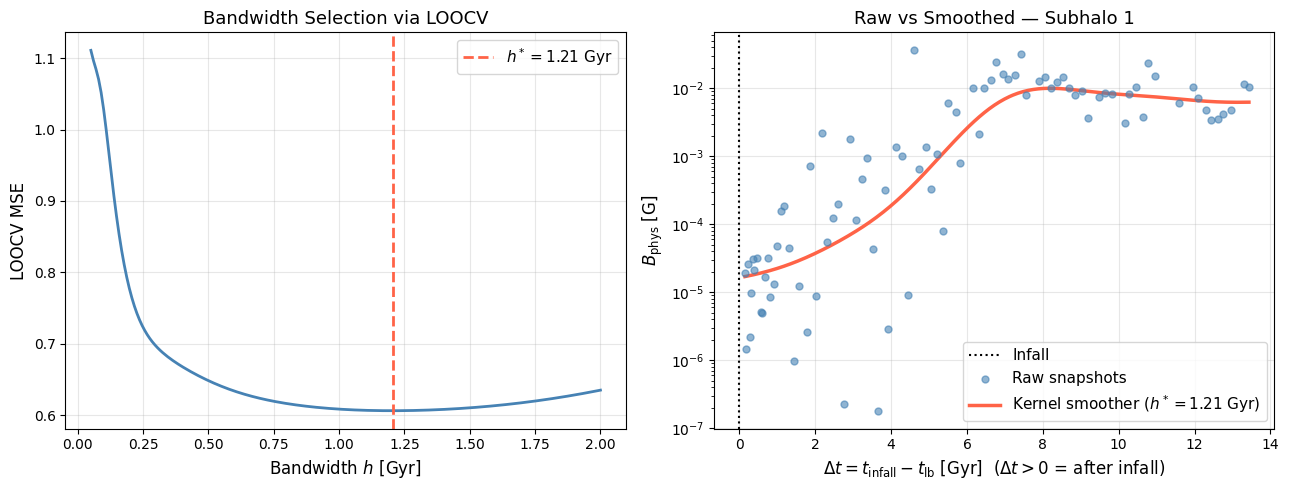

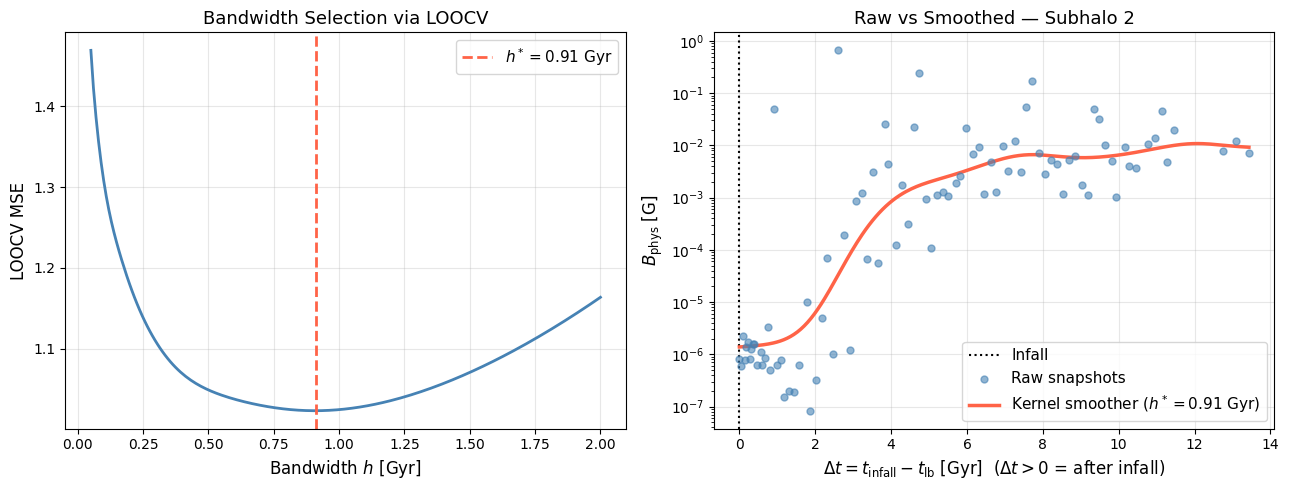

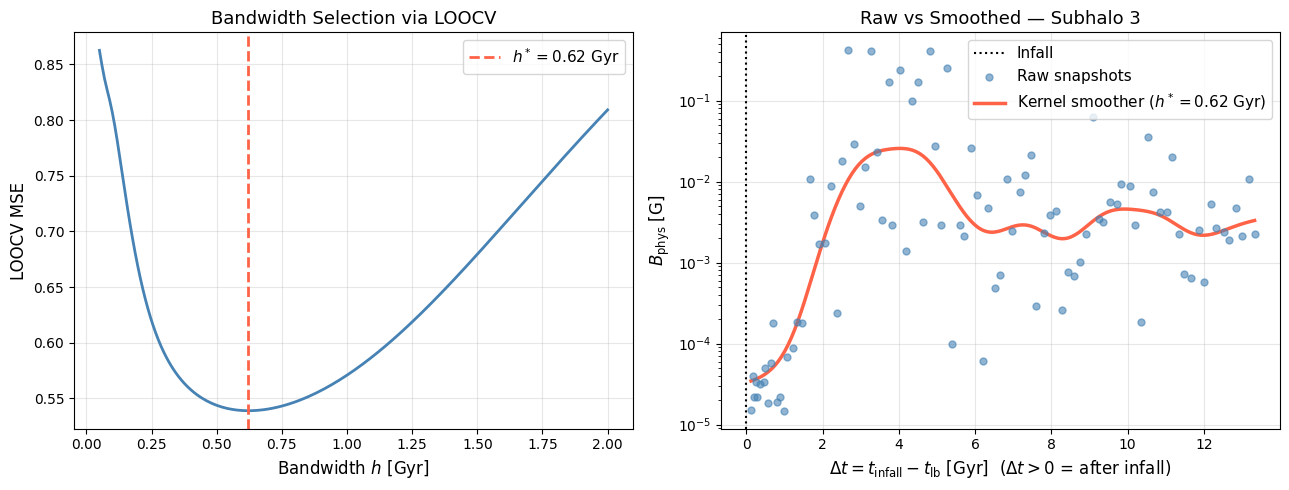

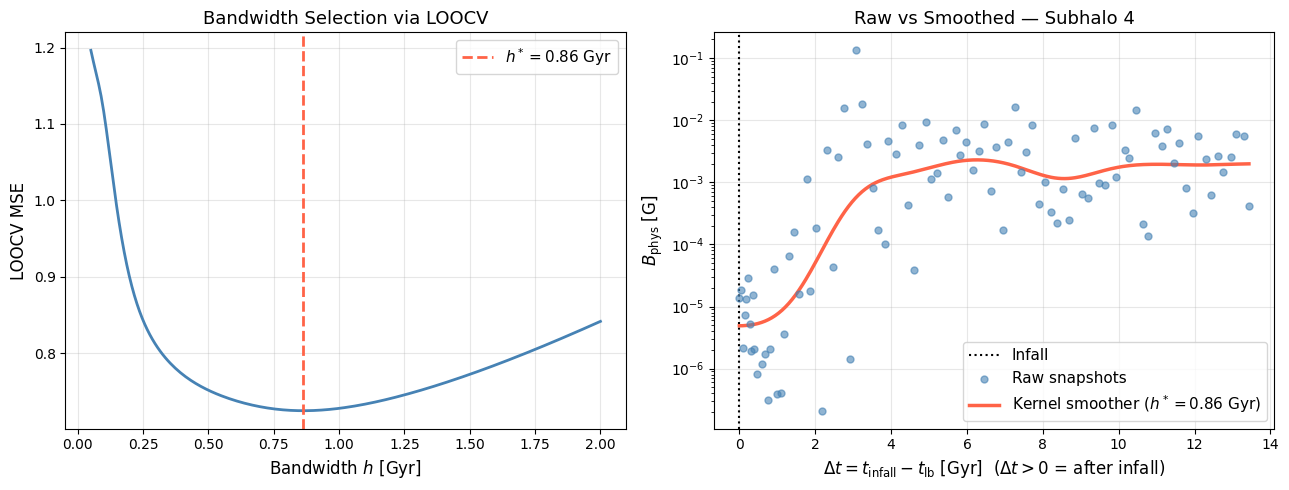

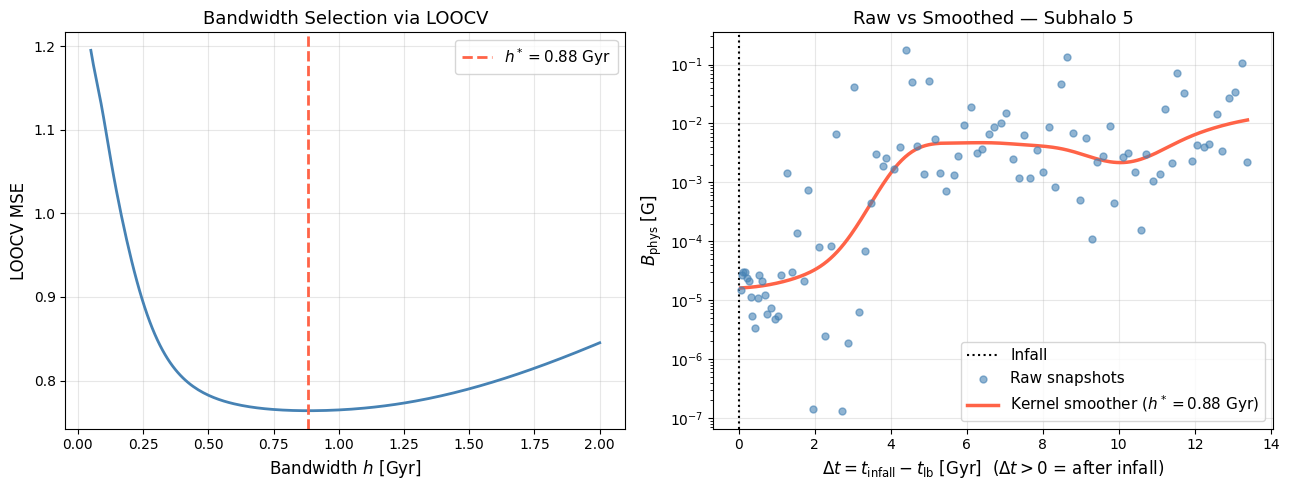

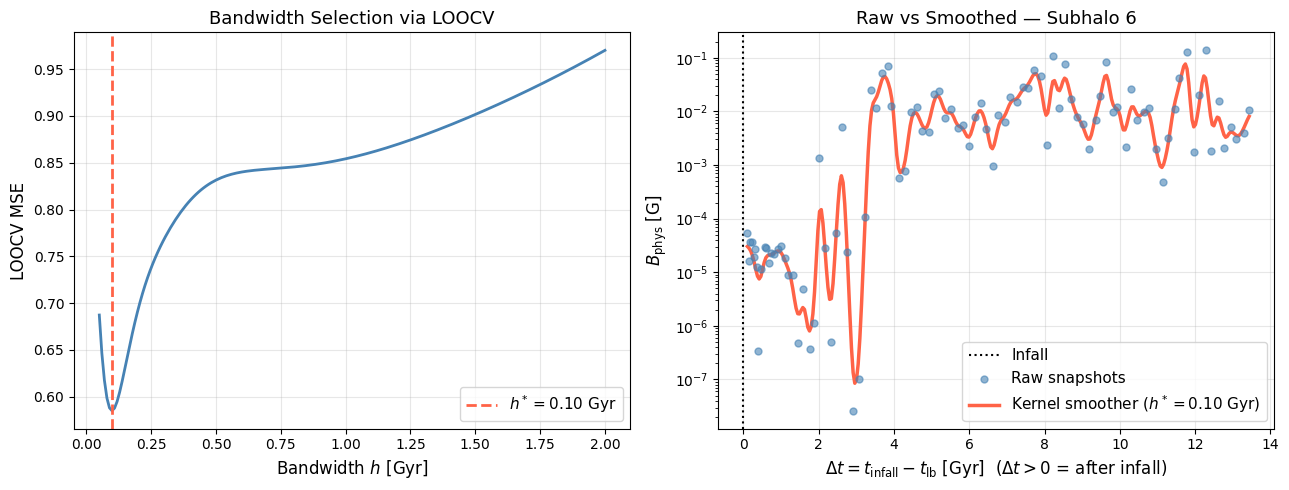

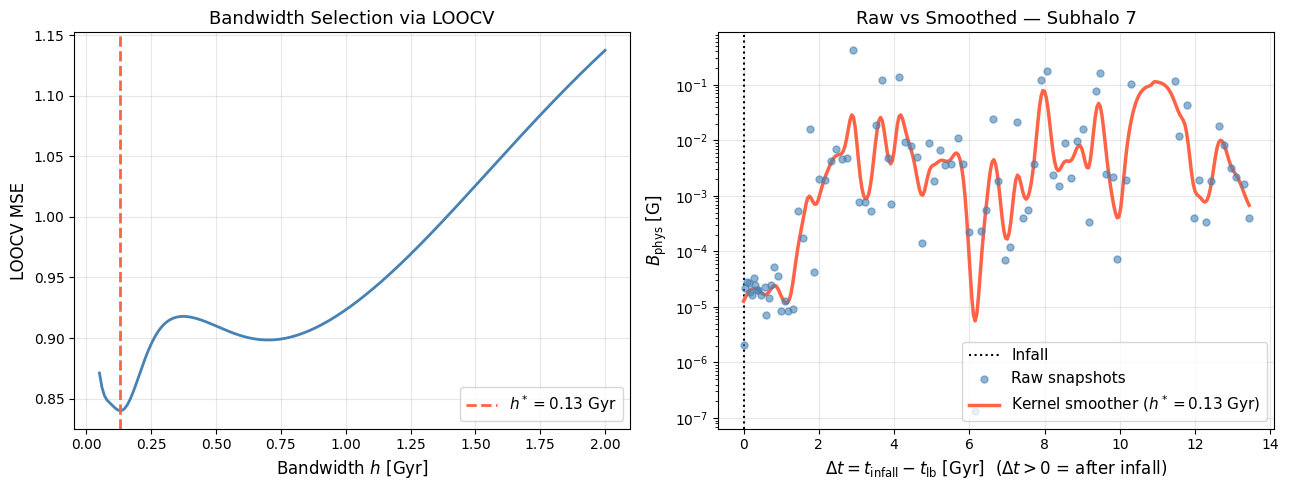

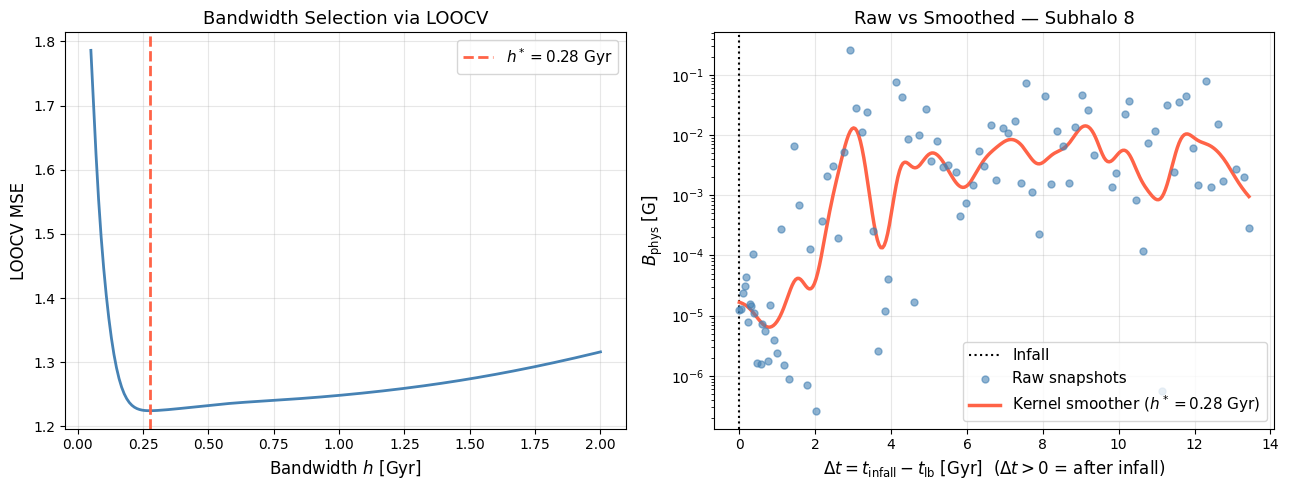

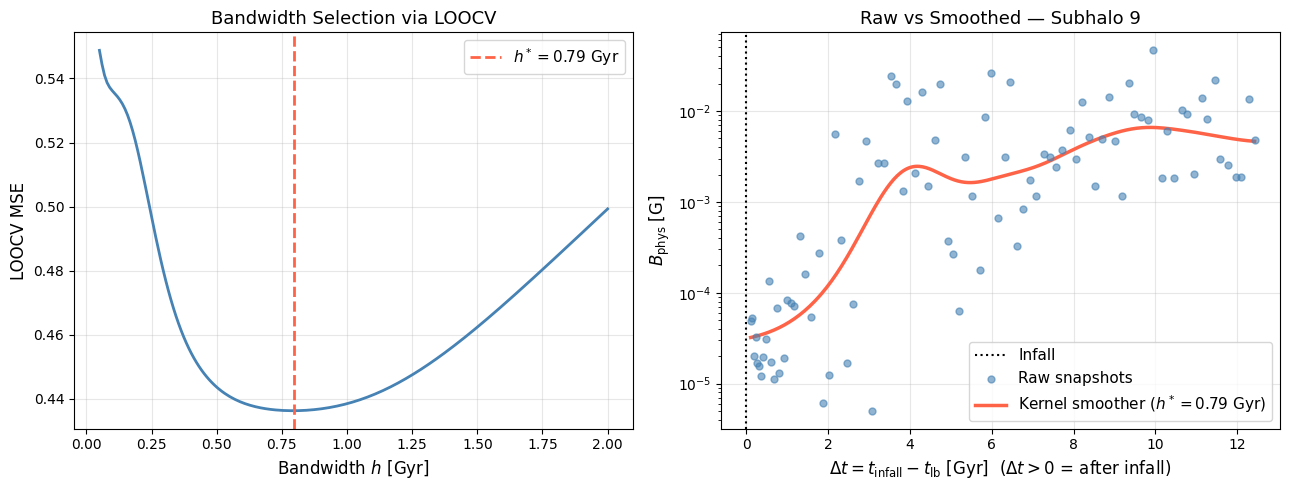

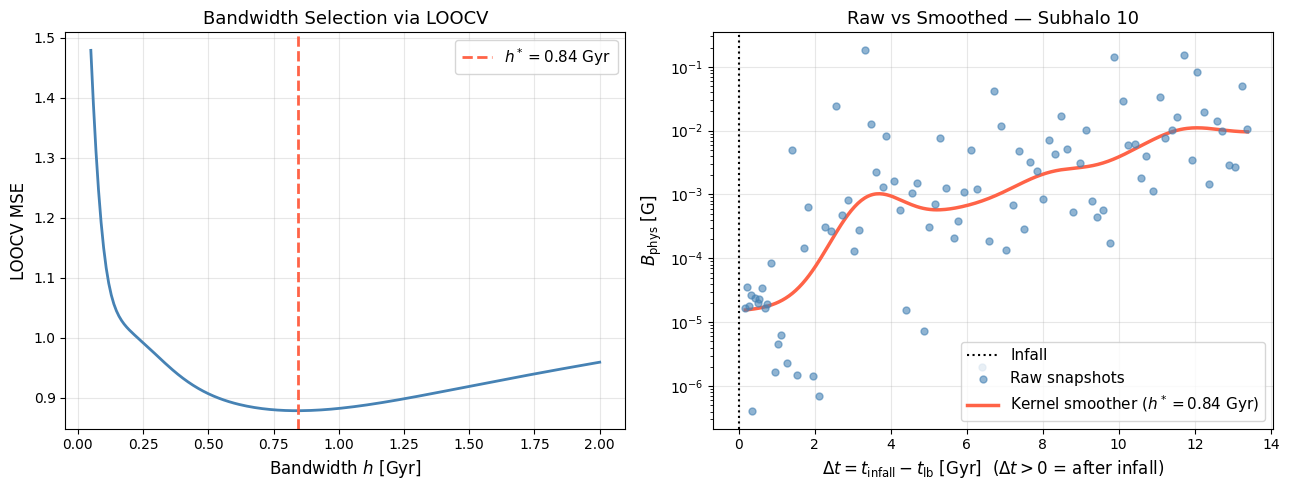

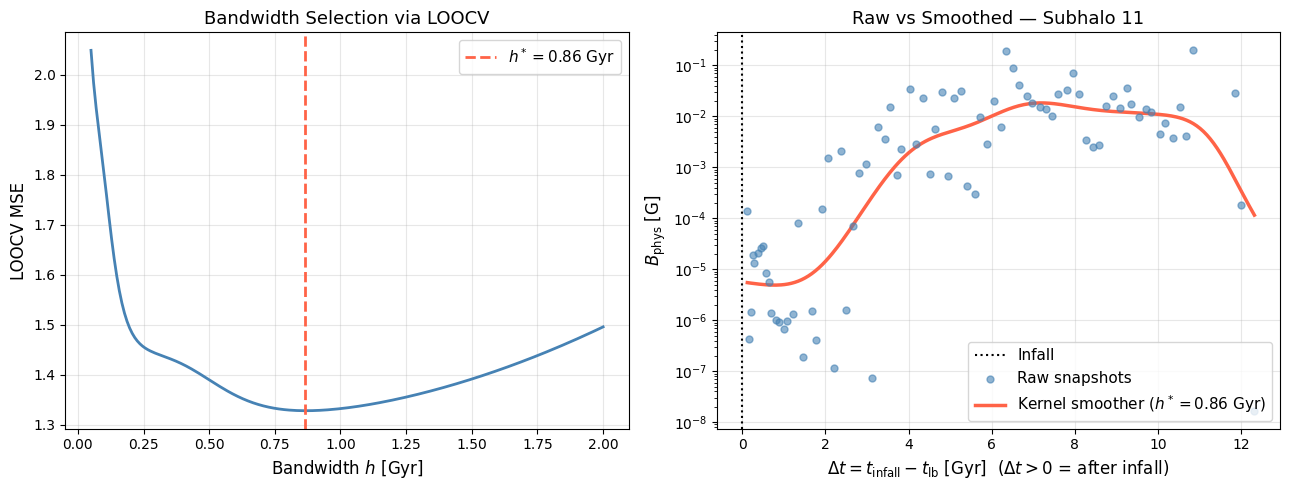

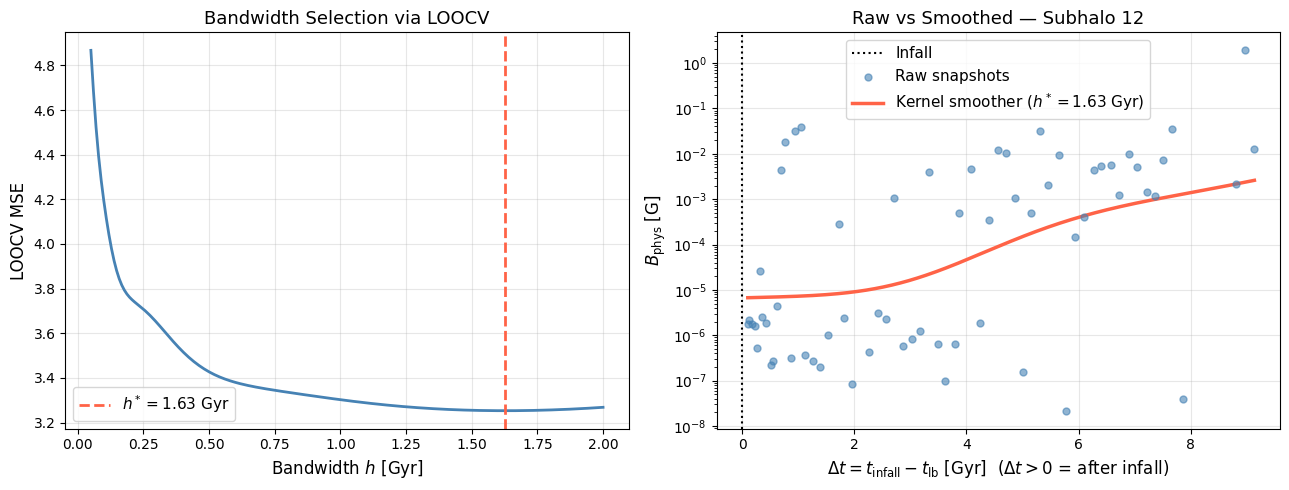

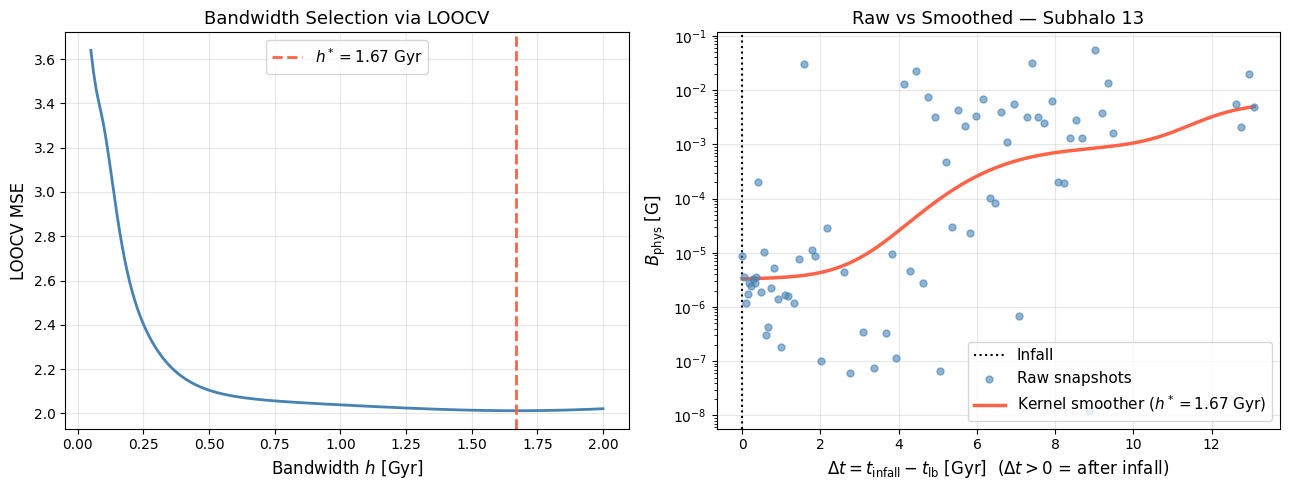

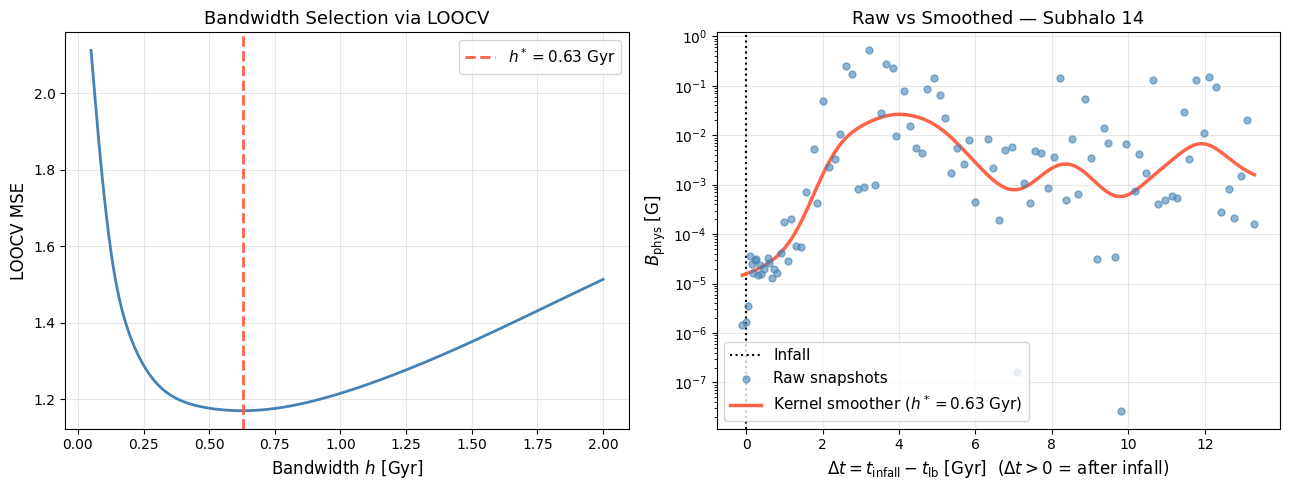

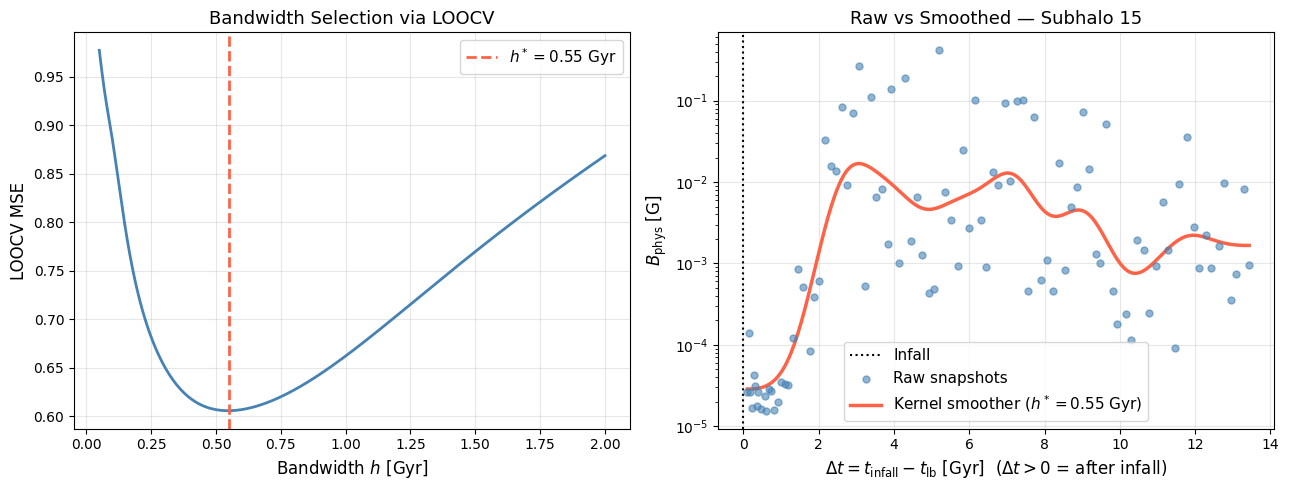

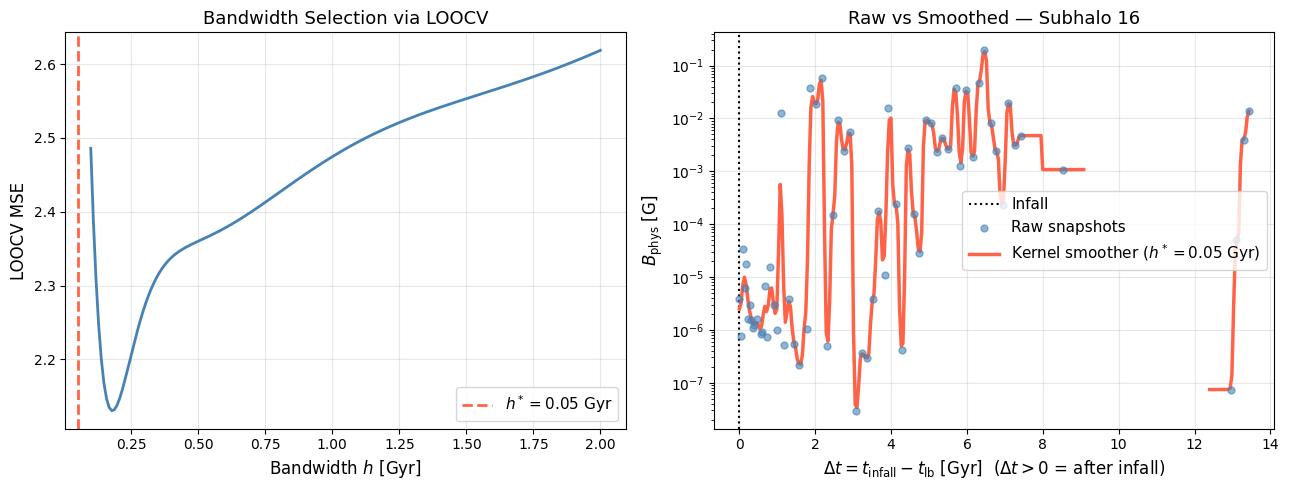

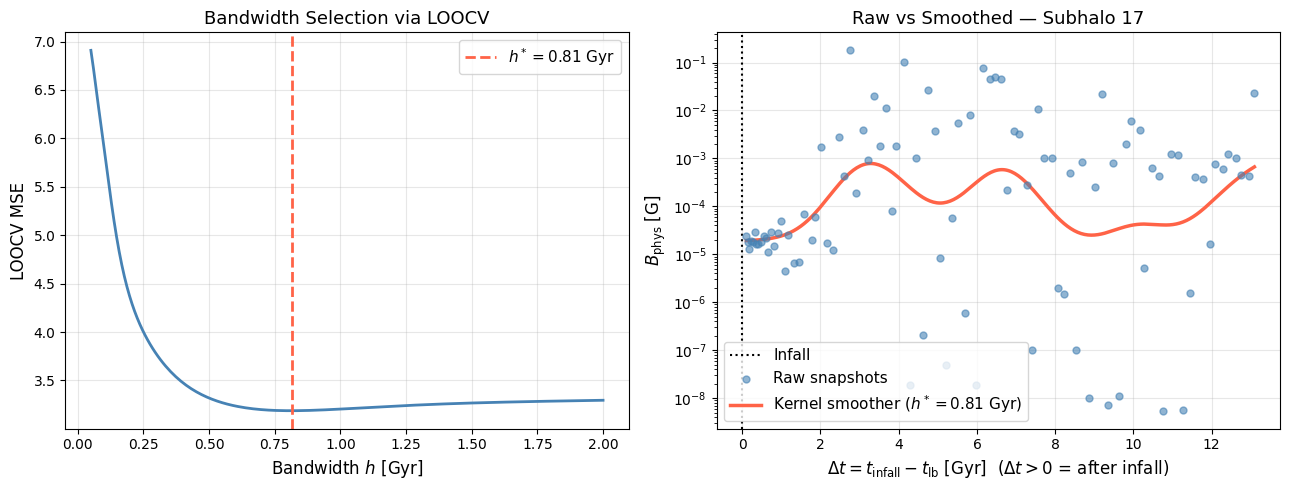

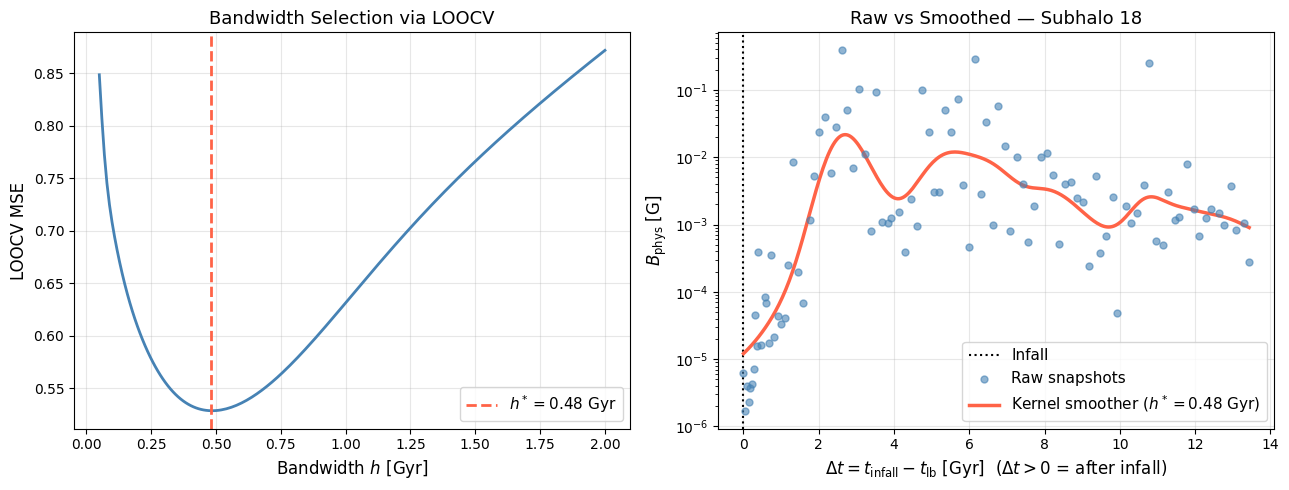

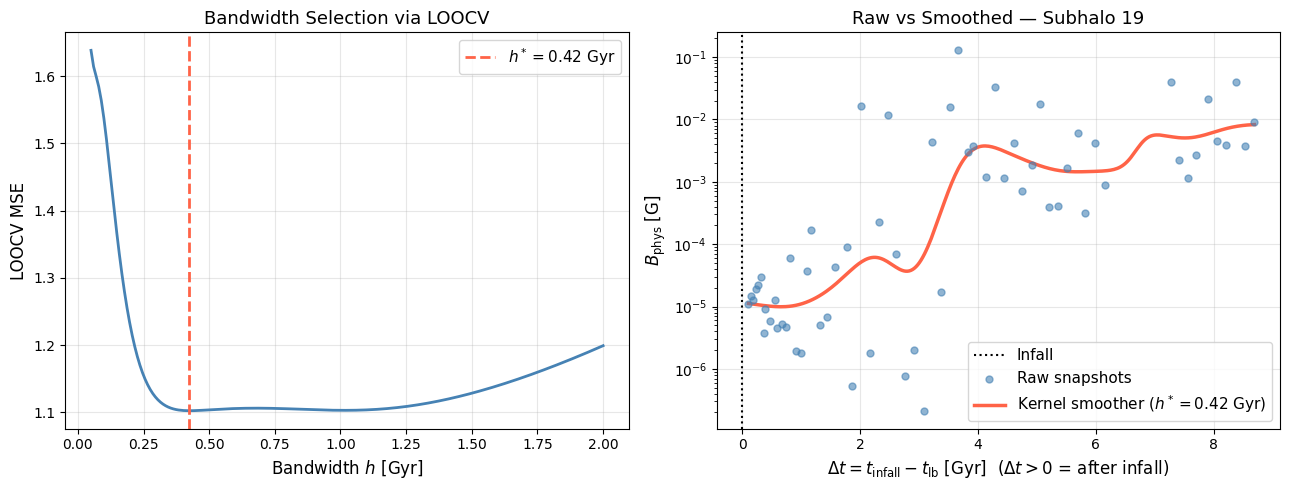

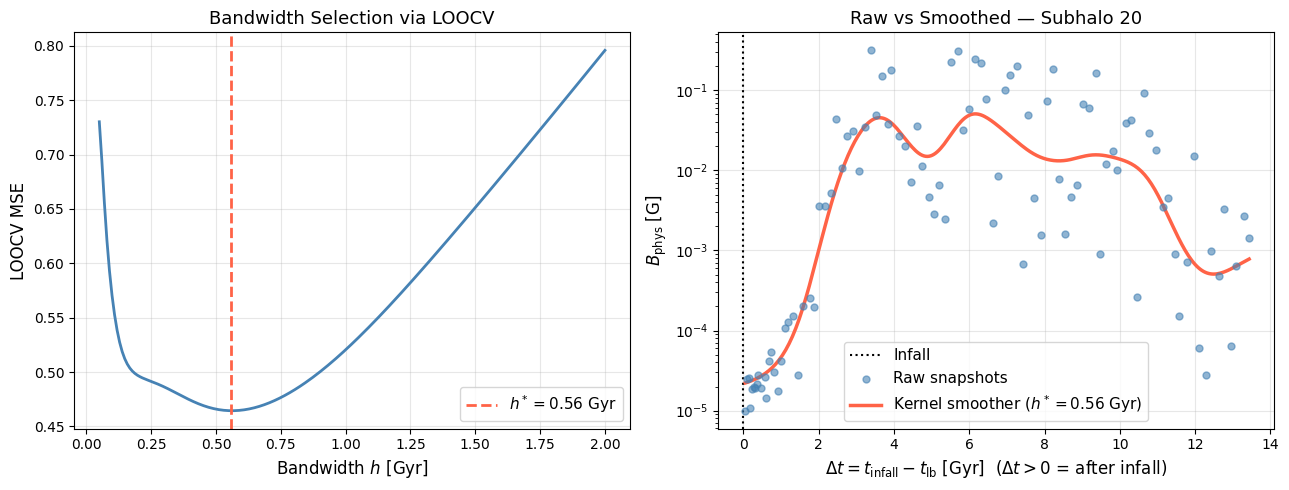

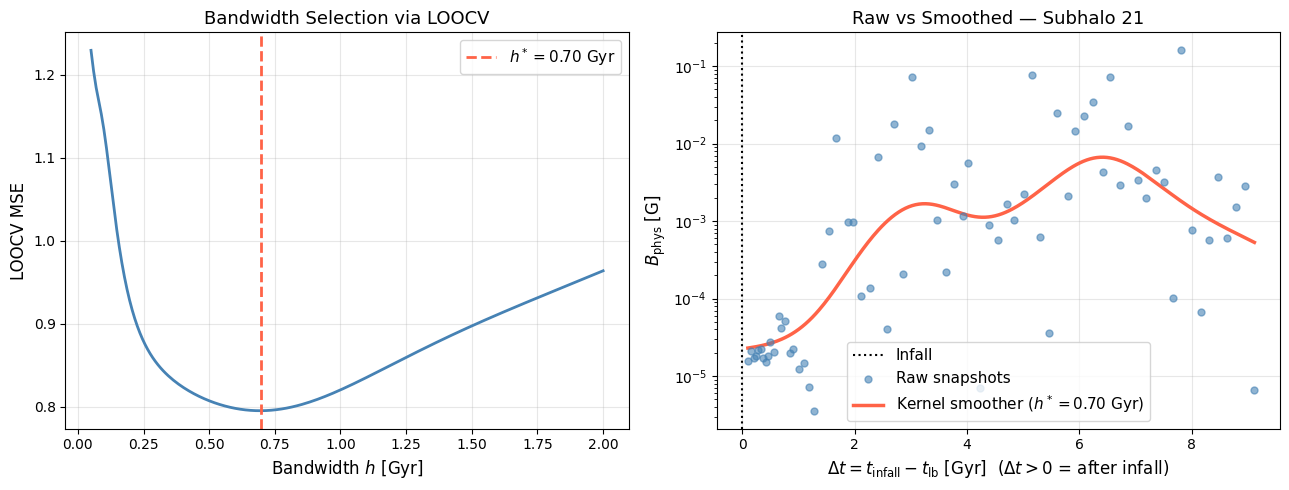

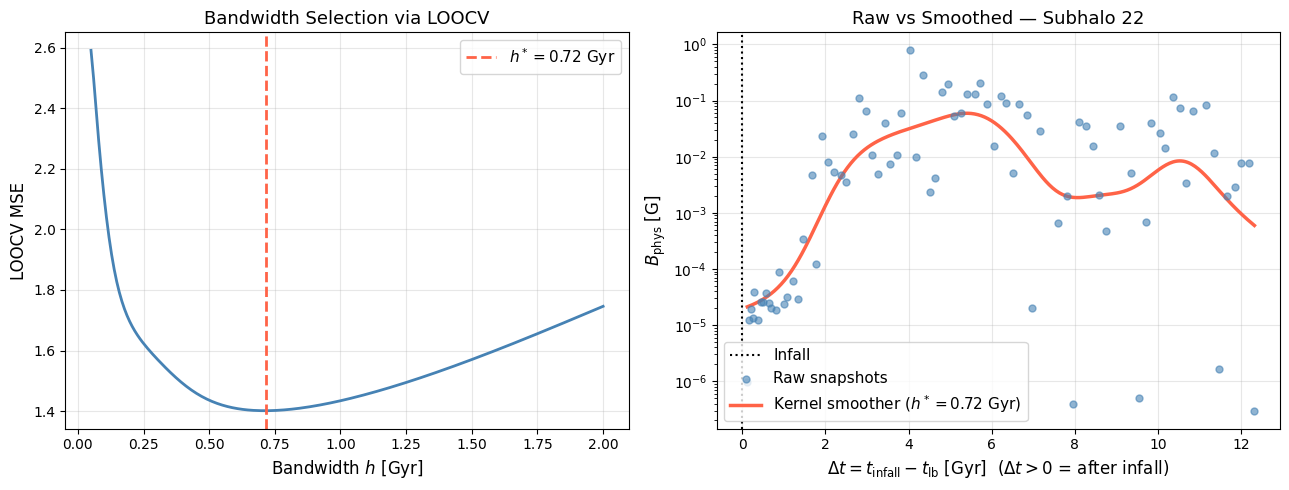

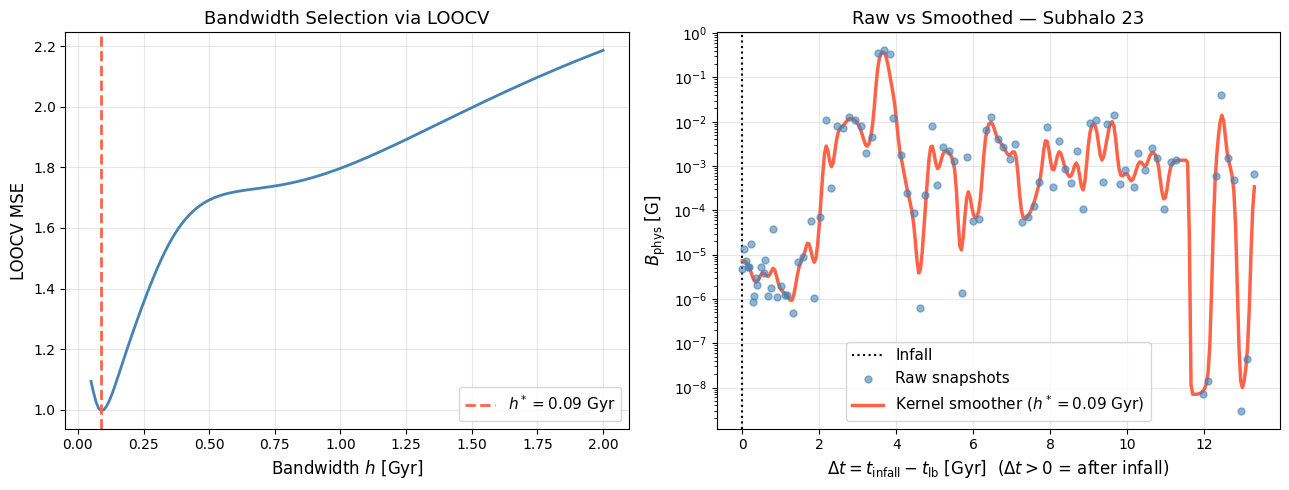

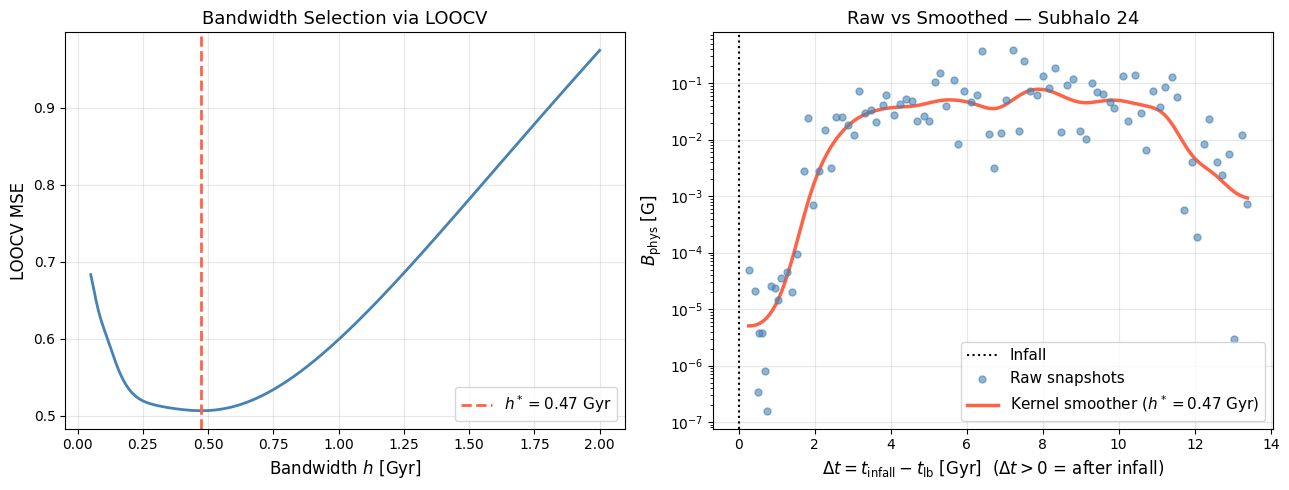

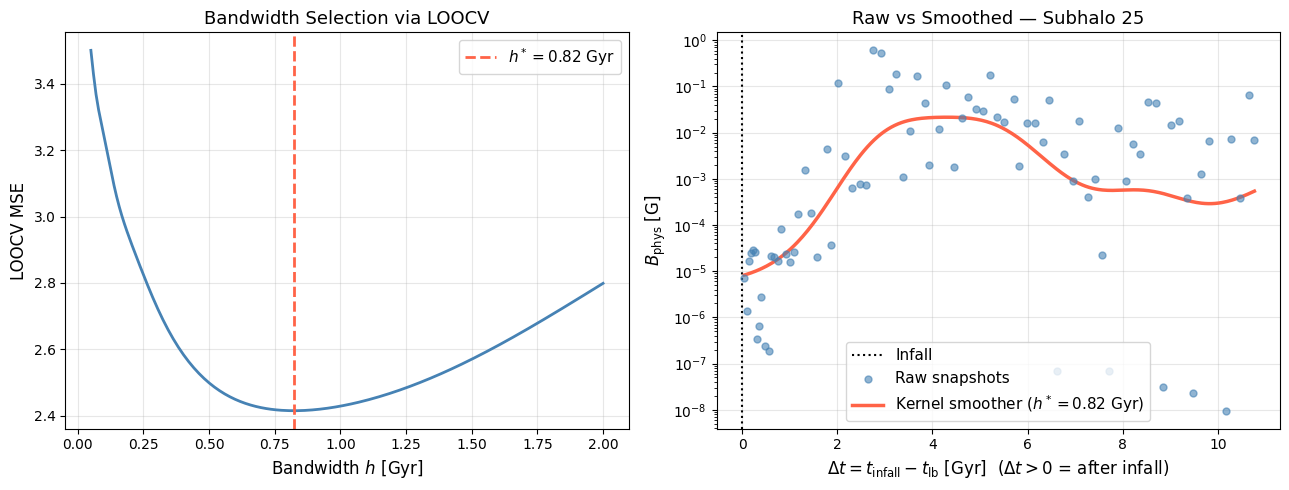

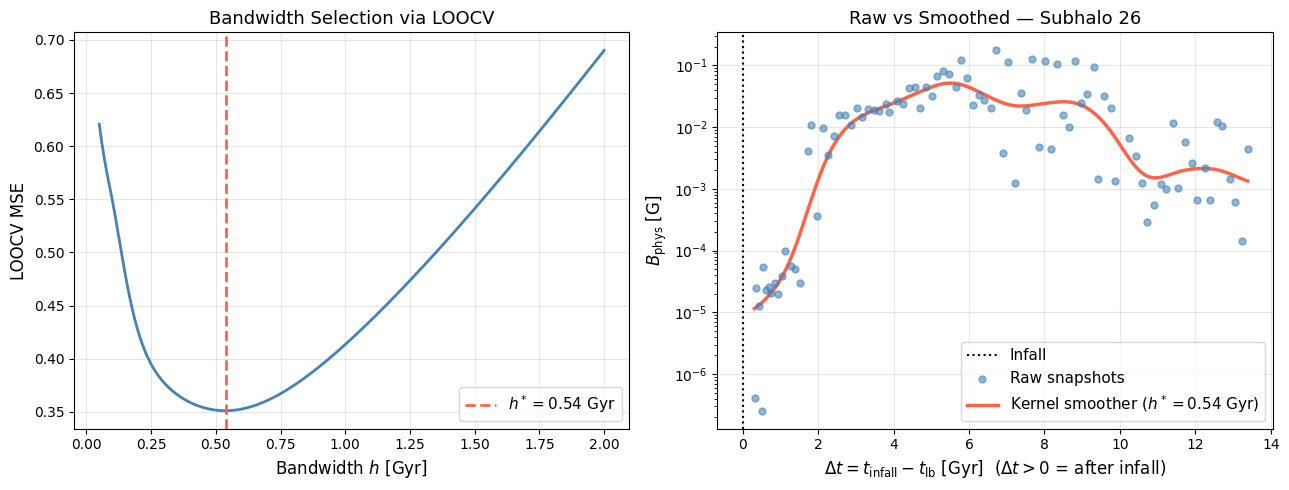

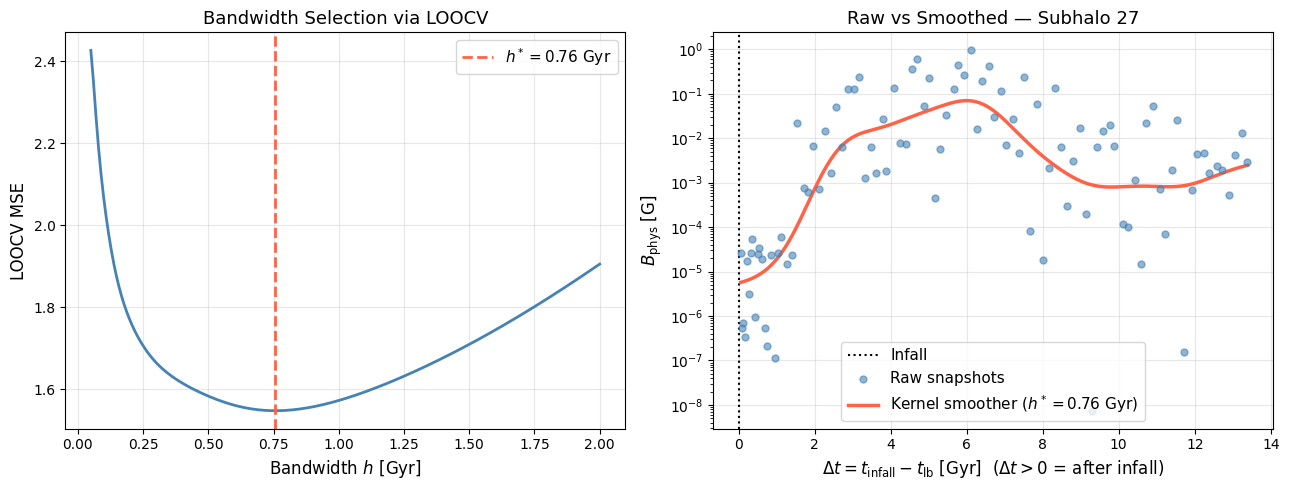

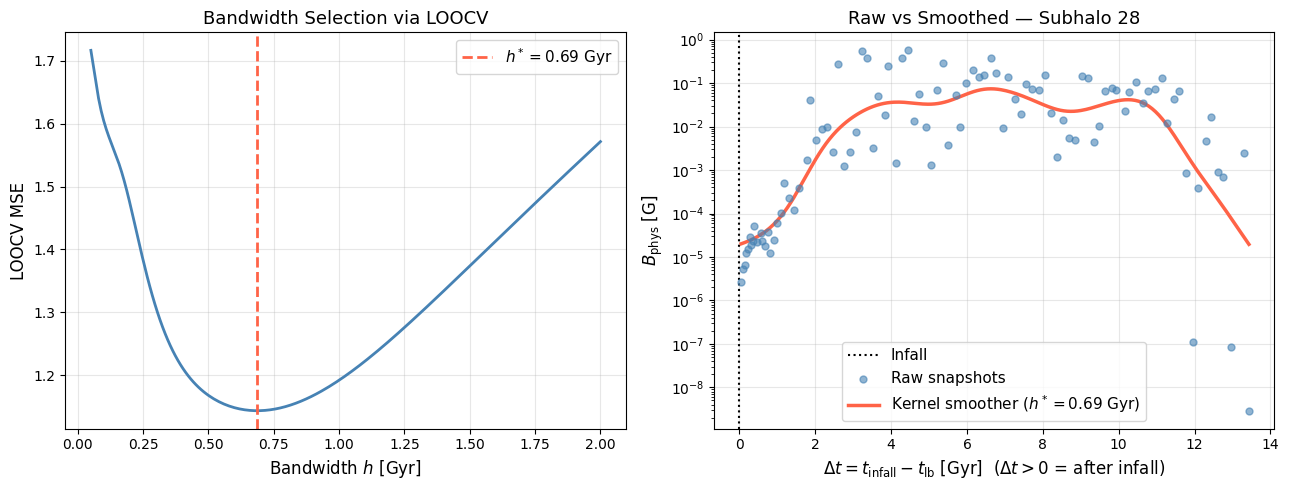

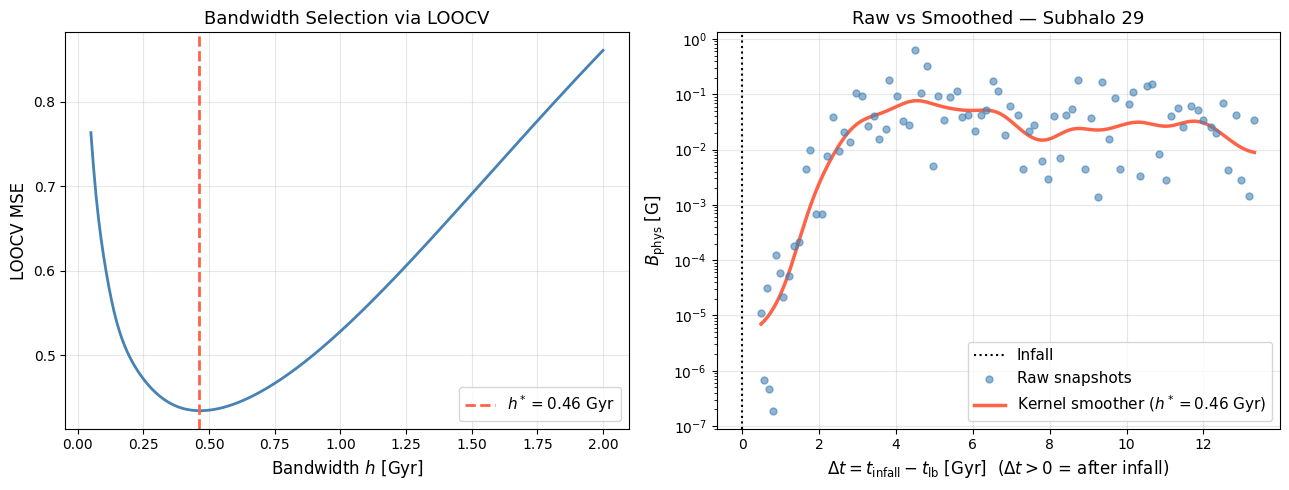

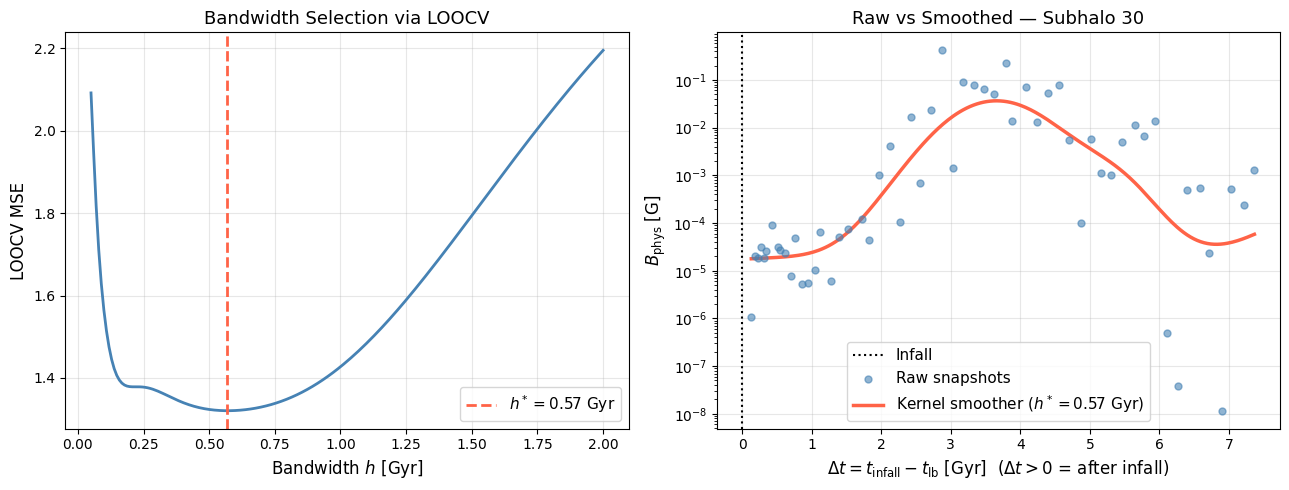

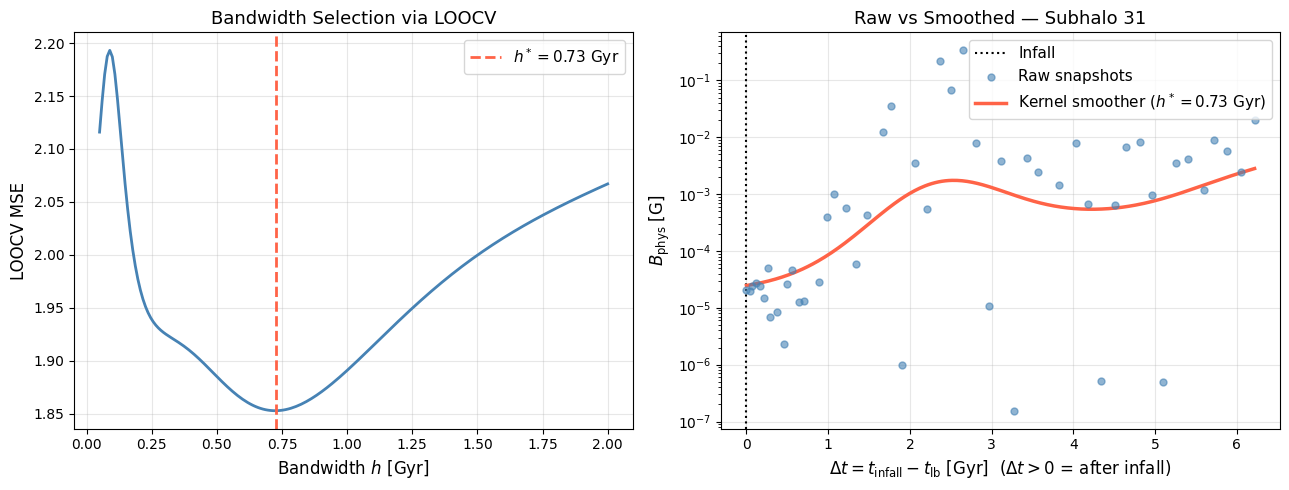

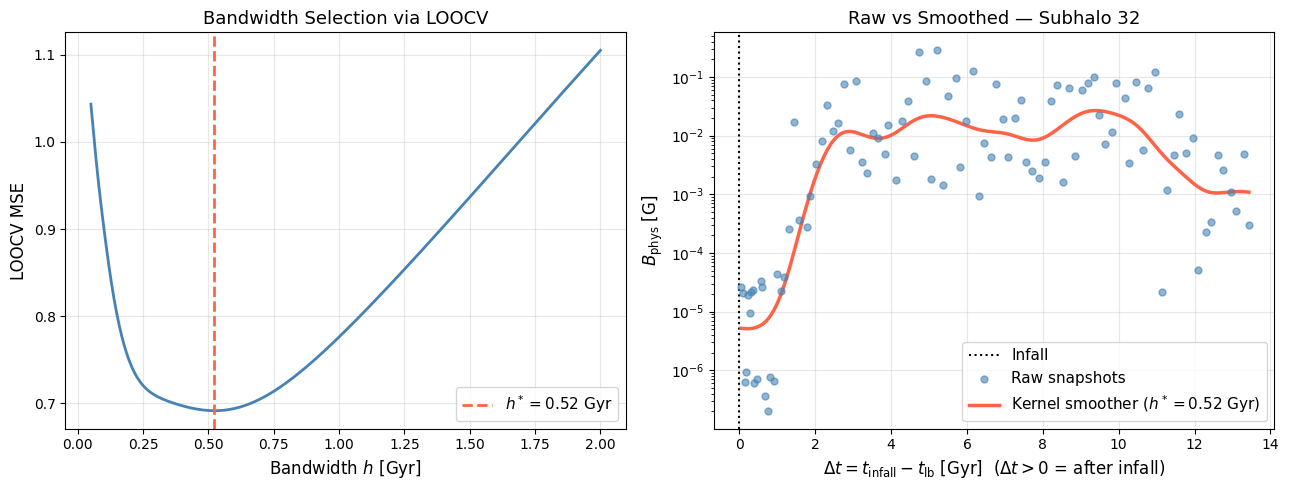

In [ ]:
def smooth_all_galaxies(all_galaxies, field='B_disk_phys'):
    """
    Apply kernel smoothing with LOOCV bandwidth selection to every galaxy in the sample.

    Adds a 'smooth' key to each galaxy dict containing the result of smooth_galaxy().
    If a galaxy has fewer than 5 valid snapshots, 'smooth' is set to None.

    Parameters
    ----------
    all_galaxies : list of dicts from process_all_satellites()
    field        : str, which B-field to smooth

    Returns
    -------
    all_galaxies : same list, with 'smooth' key added to each entry
    """
    for i, gal in enumerate(all_galaxies):
        print(f'[{i+1}/{len(all_galaxies)}] Smoothing SubhaloID {gal["subhalo_id"]} ...', end=' ')
        result        = smooth_galaxy(gal['mpb'], gal['infall'], field=field)
        gal['smooth'] = result
        if result:
            print(f'h* = {result["h_opt"]:.2f} Gyr')
        else:
            print('skipped (fewer than 5 valid data points)')
    return all_galaxies


# Apply smoothing to all galaxies
all_galaxies = smooth_all_galaxies(all_galaxies)

# Update the cache with smoothing results so we don't re-run LOOCV next time
with open(cache, 'wb') as f:
    pickle.dump(all_galaxies, f)

# Print summary statistics on the selected bandwidths
h_vals = [g['smooth']['h_opt'] for g in all_galaxies if g['smooth']]
print(f"\nSuccessfully smoothed : {len(h_vals)} galaxies")
if h_vals:
    print(f"Median h*             : {np.median(h_vals):.2f} Gyr")
    print(f"Range                 : {min(h_vals):.2f} - {max(h_vals):.2f} Gyr")

# Plot LOOCV diagnostic for every galaxy
for gal in all_galaxies:
    plot_smoothing_diagnostics(gal['smooth'], subhalo_id=gal['subhalo_id'])

---
## 9. Smoothed B-field vs Time Since Infall (Key Science Plot)

This is the central result of the project. We align all smoothed B-field tracks at $\Delta t = 0$ (infall)
and plot them together to reveal the population-level trend.

To ensure the median (orange) aligns correctly with the individual tracks (blue), we interpolate
every galaxy's smoothed curve onto a **single shared time grid** before computing statistics.
The median is computed only at grid points where at least 3 galaxies have coverage.

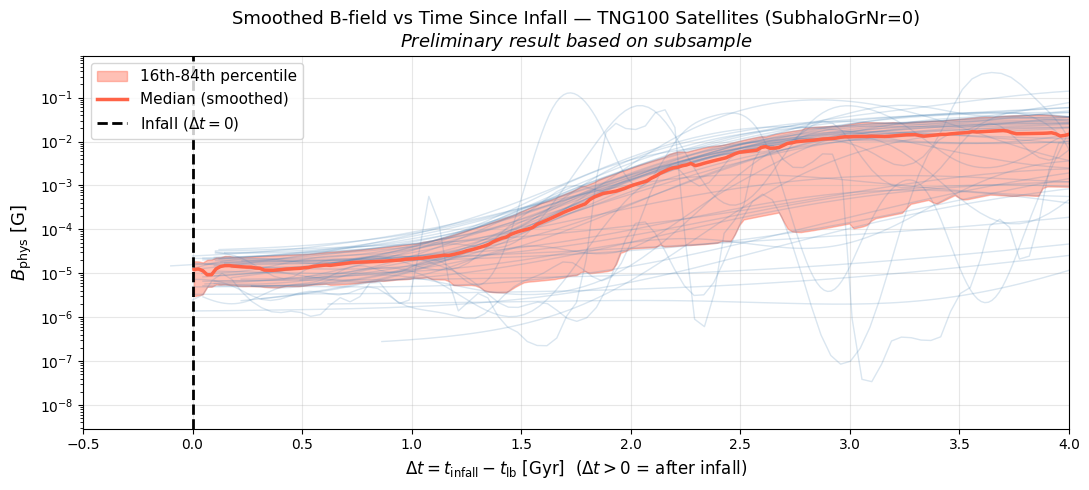

In [ ]:
def plot_smoothed_ensemble(all_galaxies, dt_range=(-2, 4), bin_width=0.5):
    """
    Overlay smoothed B-field tracks aligned at infall, with population median.

    All smoothed tracks are interpolated onto a common time grid so that the
    median (red line) and percentile band (red shading) exactly align with
    the individual galaxy tracks (blue lines).

    The median is only plotted where at least 3 galaxies have coverage,
    to avoid misleading statistics from sparse data.

    Parameters
    ----------
    all_galaxies : list of dicts with 'smooth' key from smooth_all_galaxies()
    dt_range     : tuple (min, max) Delta_t range in Gyr to plot
    bin_width    : float, not used (kept for compatibility)
    """
    fig, ax = plt.subplots(figsize=(11, 5))

    # Build a common time grid spanning dt_range
    t_common   = np.linspace(dt_range[0], dt_range[1], 300)
    all_B_grid = []  # will hold one interpolated track per galaxy

    for gal in all_galaxies:
        s = gal['smooth']
        if s is None or 'dt_fine' not in s:
            continue  # skip galaxies with no smoothing result or no infall

        # Plot this galaxy's smoothed track (faint blue)
        ax.plot(s['dt_fine'], s['B_smooth'], color='steelblue', alpha=0.2, lw=1)

        # Interpolate this galaxy's track onto the common grid
        # fill_value=np.nan means no extrapolation beyond the galaxy's time range
        try:
            f_interp = interp1d(s['dt_fine'], s['B_smooth'],
                                bounds_error=False, fill_value=np.nan)
            all_B_grid.append(f_interp(t_common))
        except Exception:
            continue

    if not all_B_grid:
        print('No smoothed tracks found — check that smooth_all_galaxies() ran successfully.')
        return

    # Stack into a 2D array: shape (n_galaxies, 300)
    all_B_grid = np.array(all_B_grid)

    # Compute median and 16th/84th percentiles at each time point
    # Only compute where at least 3 galaxies have valid data
    median = np.full(300, np.nan)
    p16    = np.full(300, np.nan)
    p84    = np.full(300, np.nan)
    for k in range(300):
        col   = all_B_grid[:, k]             # all galaxies at this time point
        valid = col[np.isfinite(col)]        # drop NaNs (galaxies with no coverage here)
        if len(valid) >= 3:
            median[k] = np.median(valid)
            p16[k]    = np.percentile(valid, 16)  # 1-sigma lower bound
            p84[k]    = np.percentile(valid, 84)  # 1-sigma upper bound

    valid_mask = np.isfinite(median)
    ax.fill_between(t_common[valid_mask], p16[valid_mask], p84[valid_mask],
                    alpha=0.4, color='tomato', label='16th-84th percentile')
    ax.plot(t_common[valid_mask], median[valid_mask],
            color='tomato', lw=2.5, label='Median (smoothed)')
    ax.axvline(0, color='black', lw=2, ls='--', label='Infall ($\\Delta t = 0$)')

    ax.set_yscale('log')
    ax.set_xlim(-0.5, 4)  # crop to region with good coverage
    ax.set_xlabel(r'$\Delta t = t_{\rm infall} - t_{\rm lb}$ [Gyr]  ($\Delta t > 0$ = after infall)', fontsize=12)
    ax.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=13)
    ax.set_title('Smoothed B-field vs Time Since Infall — TNG100 Satellites (SubhaloGrNr=0)\n'
                 r'$\it{Preliminary\ result\ based\ on\ subsample}$', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'B_smoothed_vs_dt_infall.png', dpi=150)  # fixed filename
    plt.show()


plot_smoothed_ensemble(all_galaxies)

---
## 10. Individual Exponential Fits + Distribution of Timescales

Following McDonough & Poulin (2025) and the course instructor's suggestion, we fit a physically
motivated saturating growth model to the post-infall ($\Delta t > 0$) smoothed track of **each galaxy individually**:

$$B(\Delta t) = B_0\left(1 - e^{-\Delta t / \tau}\right)$$

where:
- $B_0$ is the **saturation field strength** (the asymptotic value the field grows toward)
- $\tau$ is the **amplification timescale** in Gyr (how quickly the field reaches saturation)

Rather than fitting a single ensemble average (which would be misleading if galaxies have
different timescales), we fit each galaxy independently and plot the **distribution** of $\tau$ values.
This is the approach recommended by the course instructor.

In [ ]:
def exponential_growth(dt, B0, tau):
    """
    Saturating exponential growth model for post-infall B-field amplification.

    B(dt) = B0 * (1 - exp(-dt / tau))

    Physical interpretation:
    - At dt=0 (infall): B = 0 (field starts amplifying from near zero)
    - As dt -> infinity: B -> B0 (field saturates at B0)
    - tau controls how fast saturation is reached

    Parameters
    ----------
    dt  : float or array, time since infall in Gyr (dt > 0 = after infall)
    B0  : float, saturation field strength in Gauss
    tau : float, amplification timescale in Gyr

    Returns
    -------
    B : float or array, predicted B-field strength
    """
    return B0 * (1 - np.exp(-dt / tau))


def fit_single_galaxy(gal):
    """
    Fit the exponential growth model to one galaxy's post-infall smoothed track.

    Uses scipy.optimize.curve_fit (nonlinear least squares) to find the
    best-fit B0 and tau. Parameter uncertainties are estimated from the
    square root of the diagonal of the covariance matrix.

    Parameters
    ----------
    gal : dict with 'smooth' key from smooth_all_galaxies()

    Returns
    -------
    dict with keys: B0, tau, B0_err, tau_err, subhalo_id
    or None if the fit fails or there are fewer than 3 post-infall points
    """
    s = gal['smooth']
    if s is None or 'dt_fine' not in s:
        return None

    # Only fit the post-infall portion (dt > 0)
    mask = s['dt_fine'] > 0
    x = s['dt_fine'][mask]    # time since infall in Gyr
    y = s['B_smooth'][mask]   # smoothed B-field in Gauss

    if len(x) < 3:
        return None  # need at least 3 points to fit 2 parameters

    try:
        # Initial guess: B0 = max observed value, tau = 2 Gyr
        # Bounds prevent unphysical negative values or extremely large tau
        popt, pcov = curve_fit(exponential_growth, x, y,
                               p0=[y.max(), 2.0],
                               bounds=([0, 0.1], [np.inf, 20]),
                               maxfev=5000)
        # Parameter uncertainties from the square root of the covariance diagonal
        perr = np.sqrt(np.diag(pcov))
        return {'B0'         : popt[0],
                'tau'        : popt[1],
                'B0_err'     : perr[0],
                'tau_err'    : perr[1],
                'subhalo_id' : gal['subhalo_id']}
    except RuntimeError:
        return None  # curve_fit failed to converge


def fit_all_and_plot_distributions(all_galaxies):
    """
    Fit the exponential growth model to each galaxy individually, then
    plot distributions of the fitted parameters (tau and B0) across the sample.

    This approach (per-galaxy fits + distribution) is preferred over fitting
    the ensemble median, because different galaxies may have different timescales,
    and averaging them first would lose that information.

    Produces three figures:
      1. Histograms of tau and B0 distributions
      2. Individual smoothed tracks with their exponential fits overlaid

    Parameters
    ----------
    all_galaxies : list of dicts from smooth_all_galaxies()

    Returns
    -------
    fits : list of dicts, one per successfully fitted galaxy
    """
    # Fit each galaxy and collect results
    fits = []
    for gal in all_galaxies:
        result = fit_single_galaxy(gal)
        if result:
            fits.append(result)
            print(f"SubhaloID {result['subhalo_id']:>8d} :  "
                  f"tau = {result['tau']:.2f} +/- {result['tau_err']:.2f} Gyr  |  "
                  f"B0 = {result['B0']:.3e} G")
        else:
            print(f"SubhaloID {gal['subhalo_id']:>8d} :  fit failed or insufficient post-infall data")

    if not fits:
        print('No successful fits — try expanding the sample or checking the smoothing results.')
        return []

    # Extract fitted parameter values
    taus = [f['tau'] for f in fits]
    B0s  = [f['B0']  for f in fits]

    # Print summary statistics
    print(f'\nNumber of successful fits : {len(fits)}')
    print(f'Median tau : {np.median(taus):.2f} Gyr')
    print(f'Mean tau   : {np.mean(taus):.2f} Gyr')
    print(f'Std tau    : {np.std(taus):.2f} Gyr')

    # ── Figure 1: Distribution histograms ────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Left: distribution of amplification timescales tau
    ax1.hist(taus, bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    ax1.axvline(np.median(taus), color='tomato', lw=2, ls='--',
                label=f'Median = {np.median(taus):.2f} Gyr')
    ax1.set_xlabel(r'Amplification timescale $\tau$ [Gyr]', fontsize=12)
    ax1.set_ylabel('Number of galaxies', fontsize=12)
    ax1.set_title(r'Distribution of $\tau$ — SubhaloGrNr = 0', fontsize=13)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Right: distribution of saturation field strengths B0 (in log space)
    ax2.hist(np.log10(B0s), bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    ax2.axvline(np.median(np.log10(B0s)), color='tomato', lw=2, ls='--',
                label=f'Median = {np.median(np.log10(B0s)):.2f}')
    ax2.set_xlabel(r'$\log_{10}(B_0\,[\mathrm{G}])$', fontsize=12)
    ax2.set_ylabel('Number of galaxies', fontsize=12)
    ax2.set_title(r'Distribution of $B_0$ — SubhaloGrNr = 0', fontsize=13)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'tau_B0_distributions.png', dpi=150)
    plt.show()

    # ── Figure 2: Individual tracks + fits overlaid ───────────────────────────
    fig, ax = plt.subplots(figsize=(11, 5))
    for f in fits:
        # Find this galaxy's smoothing result
        gal  = next(g for g in all_galaxies if g['subhalo_id'] == f['subhalo_id'])
        s    = gal['smooth']
        mask = s['dt_fine'] > 0

        # Plot smoothed track (blue) and fitted model (red dashed)
        ax.plot(s['dt_fine'][mask], s['B_smooth'][mask],
                color='steelblue', alpha=0.3, lw=1)
        t_fit = np.linspace(0, s['dt_fine'][mask].max(), 200)
        ax.plot(t_fit, exponential_growth(t_fit, f['B0'], f['tau']),
                color='tomato', alpha=0.5, lw=1.5, ls='--')

    ax.set_yscale('log')
    ax.set_xlabel(r'$\Delta t$ [Gyr]  ($\Delta t > 0$ = after infall)', fontsize=12)
    ax.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=12)
    ax.set_title('Individual Smoothed Tracks + Exponential Fits\n'
                 'Blue = smoothed data | Red dashed = $B_0(1-e^{-\\Delta t/\\tau})$ fit\n'
                 'SubhaloGrNr = 0 satellites', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'individual_fits_grnr0.png', dpi=150)
    plt.show()

    return fits


# Run the per-galaxy exponential fits and plot distributions
fits = fit_all_and_plot_distributions(all_galaxies)

SubhaloID        1 :  tau = 20.00 +/- 8.46 Gyr  |  B0 = 1.721e-02 G
SubhaloID        2 :  tau = 20.00 +/- 5.48 Gyr  |  B0 = 1.822e-02 G
SubhaloID        3 :  tau = 0.95 +/- 0.48 Gyr  |  B0 = 6.744e-03 G
SubhaloID        4 :  tau = 5.50 +/- 0.58 Gyr  |  B0 = 2.180e-03 G
SubhaloID        5 :  tau = 20.00 +/- 9.00 Gyr  |  B0 = 1.263e-02 G
SubhaloID        6 :  tau = 5.23 +/- 2.05 Gyr  |  B0 = 1.746e-02 G
SubhaloID        7 :  tau = 20.00 +/- 29.37 Gyr  |  B0 = 5.196e-02 G
SubhaloID        8 :  tau = 4.40 +/- 1.12 Gyr  |  B0 = 5.760e-03 G
SubhaloID        9 :  tau = 20.00 +/- 6.01 Gyr  |  B0 = 1.212e-02 G
SubhaloID       10 :  tau = 20.00 +/- 11.92 Gyr  |  B0 = 1.326e-02 G
SubhaloID       11 :  tau = 5.23 +/- 1.39 Gyr  |  B0 = 1.128e-02 G
SubhaloID       12 :  tau = 20.00 +/- 19.53 Gyr  |  B0 = 2.990e-03 G
SubhaloID       13 :  tau = 20.00 +/- 15.08 Gyr  |  B0 = 3.996e-03 G
SubhaloID       14 :  tau = 0.94 +/- 0.53 Gyr  |  B0 = 6.354e-03 G
SubhaloID       15 :  tau = 1.04 +/- 0.38 Gyr  |  

ValueError: array must not contain infs or NaNs

---
## Notes

### Output file locations
All figures are saved to `repo_root/results/figures/` and all merger tree files to `repo_root/trees/`,
where `repo_root` is the top-level `Numerical_methods_Project/` folder.

### Reloading cached data
To reload processed results without re-downloading:
```python
with open(DATA_DIR / 'all_galaxies_grnr0.pkl', 'rb') as f:
    all_galaxies = pickle.load(f)
```

### Force re-download
Delete the cache file and re-run Cell 14:
```python
os.remove(DATA_DIR / 'all_galaxies_grnr0.pkl')
```

### 403 errors
Some subhalos have no merger tree in the API. The code prints a browser URL to inspect the subhalo
manually and automatically skips it. This is normal and does not indicate an account issue.

### Scaling up
Change `limit=50` in `query_satellites()` to a larger value for the final analysis.
The LOOCV step is the slowest part (~1-2 seconds per galaxy at 200 bandwidth candidates).
Cached HDF5 tree files mean re-running the notebook is much faster after the first run.